This notebook was created by Donyl Alcantara

# Network Topology of Reddit

### Overview

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.



## Section 1: Environment Configuration

#### 1.1 Environment Setup

In [273]:
import pandas as pd
import re
import zstandard as zstd
import io
import orjson
from collections import defaultdict
import json
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import csv
import polars as pl
import os
import gdown
import numpy as np
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from pathlib import Path
import powerlaw
import mapclassify
from scipy.sparse import csr_matrix
from scipy import sparse

#### 1.2 Import `user_subreddit_interactions` from `analytics`

In [71]:
df_all = pl.scan_parquet('analytics/user_subreddit_interactions.parquet').collect()
df_all 

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Shatter_starx""","""pcmasterrace""",0,22,22
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


## Section 2: Data Pre-Processing/Exploratory Data Analysis

According to [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/), due to the existence of significant noise, including the possibility of repeated interactions, specifically because of 'bot users,' we initially do the following: 

- Normalize subreddit names (done in 00)
- Filter self-referential interactions 
- Remove interactions made by top 2% users
- Remove single-interaction subreddit pairs
- Merge interactions between subreddit pairs


#### 2.1 User Activity Aggregation

In [72]:
# total interaction per author 

df_author_interaction = df_all.group_by('author').agg(
    pl.col("interaction_count").sum().alias('interaction_per_user')).sort(
    'interaction_per_user', descending=True) # convert into eager df

# create rank col
df_author_interaction = df_author_interaction.with_columns(pl.arange(
    1, df_author_interaction.height + 1).alias("rank")) # height = number of rows, width = number of cols

df_author_interaction.head(20)

author,interaction_per_user,rank
str,i64,i64
"""donut-bot""",163298,1
"""TipOfTheirTongue""",162697,2
"""VisualMod""",100202,3
"""MinecraftModBot""",89755,4
"""MrPuma86""",65225,5
…,…,…
"""Sky-876""",20904,16
"""bvandepol""",20343,17
"""AskWomen-ModTeam""",20105,18


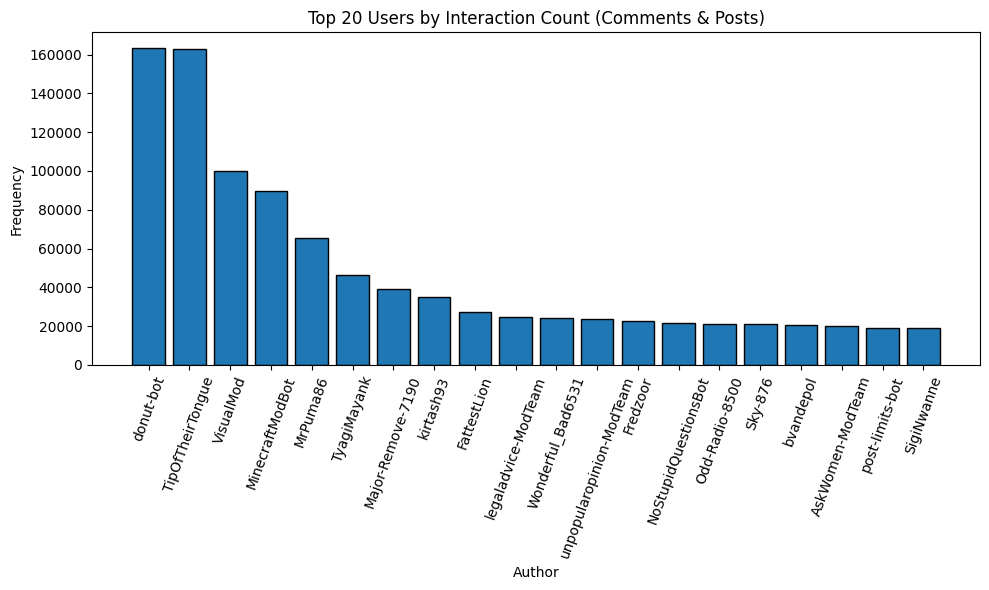

In [76]:
# top 20 

# bar graph
plt.figure(figsize=(10, 6))
plt.bar(df_author_interaction['author'].head(20),
        df_author_interaction['interaction_per_user'].head(20),
        edgecolor='black')
plt.title("Top 20 Users by Interaction Count (Comments & Posts)")
plt.xlabel("Author")
plt.ylabel("Frequency")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

#### 2.2 Rank-Frequency Profiling

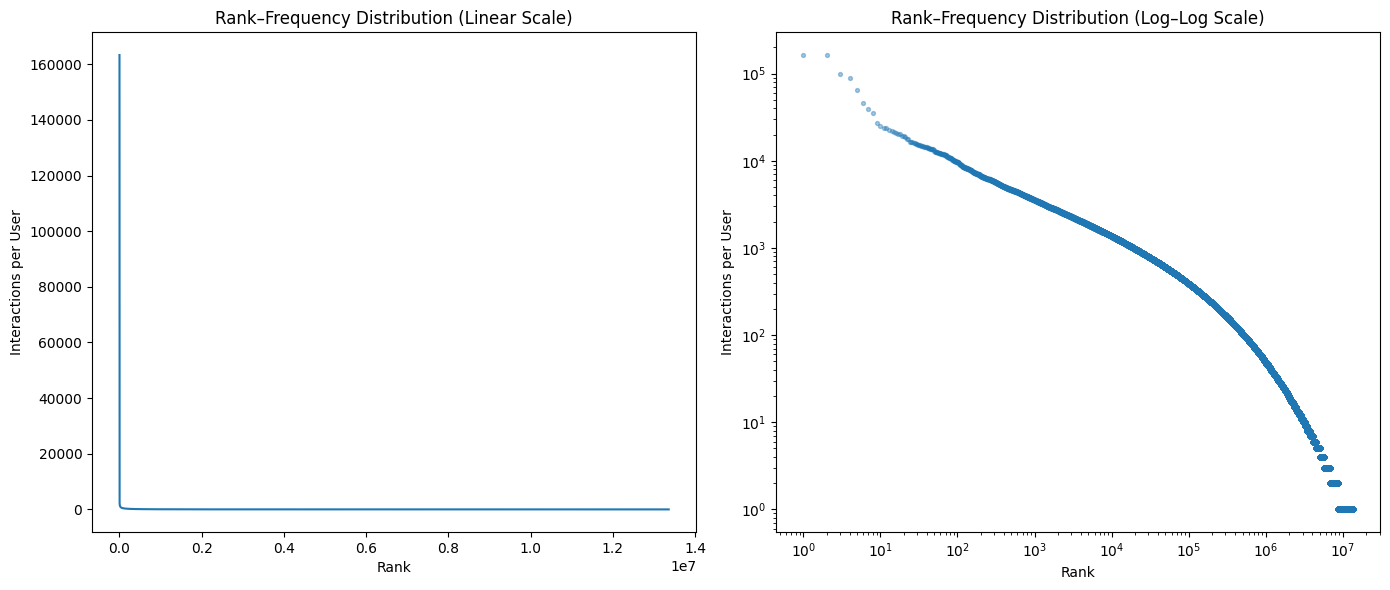

In [77]:
# visualize the long-tail dist with and without scaling
# convert polars series to numpy
x = df_author_interaction['rank'].to_numpy()
y = df_author_interaction['interaction_per_user'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Linear scale
axes[0].plot(x, y)
axes[0].set_title("Rank–Frequency Distribution (Linear Scale)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Interactions per User")

# Log–Log scale
axes[1].scatter(x, y, alpha=0.4, s=8, color='#1f77b4')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank–Frequency Distribution (Log–Log Scale)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Interactions per User")

plt.tight_layout()
plt.show()

#### 2.3 Outlier/Noise Detection 

#### Log Interquartile Range (IQR)

In [78]:
data = df_author_interaction["interaction_per_user"].to_numpy()
log_data = np.log1p(data)

Q1 = np.percentile(log_data, 25)
Q3 = np.percentile(log_data, 75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = data[log_data > upper_bound]

print(f"Outlier threshold: {np.expm1(upper_bound):.0f}")

Outlier threshold: 111


#### Contribution Share

The distribution of user activity exhibits a pronounced long-tail. We observe a high concentration of activity among a small subset of users: the top 2% of contributors account for approximately 47% of all interactions. This extreme inequality suggests that a small number of highly active users disproportionately shape the interaction network. To mitigate this bias and reduce potential noise from automated or hyperactive accounts, we remove users whose interaction counts fall within the top 2% of the distribution.

In [8]:
# sort descending
df_cs = df_author_interaction.sort("interaction_per_user", descending=True)
total_interactions = df_cs["interaction_per_user"].sum()

# iterate over top 1 to 20%
for pct in range(1, 21):
    n_top = int(df_cs.height * (pct/100))
    top_users = df_cs.head(n_top)
    share = top_users["interaction_per_user"].sum() / total_interactions
    print(f"Top {pct}% users: {n_top}, Contribution share: {share:.2f}")

Top 1% users: 133614, Contribution share: 0.35
Top 2% users: 267228, Contribution share: 0.47
Top 3% users: 400842, Contribution share: 0.55
Top 4% users: 534456, Contribution share: 0.60
Top 5% users: 668070, Contribution share: 0.65
Top 6% users: 801684, Contribution share: 0.68
Top 7% users: 935298, Contribution share: 0.71
Top 8% users: 1068912, Contribution share: 0.74
Top 9% users: 1202526, Contribution share: 0.76
Top 10% users: 1336140, Contribution share: 0.77
Top 11% users: 1469754, Contribution share: 0.79
Top 12% users: 1603368, Contribution share: 0.81
Top 13% users: 1736983, Contribution share: 0.82
Top 14% users: 1870597, Contribution share: 0.83
Top 15% users: 2004211, Contribution share: 0.84
Top 16% users: 2137825, Contribution share: 0.85
Top 17% users: 2271439, Contribution share: 0.86
Top 18% users: 2405053, Contribution share: 0.86
Top 19% users: 2538667, Contribution share: 0.87
Top 20% users: 2672281, Contribution share: 0.88


#### Lorenz Curve and Gini Coefficient

The Gini coefficient of user interactions is 0.83, indicating extreme inequality. The top 2% of users generate 47% of all interactions, confirming that a small subset of highly active users dominates the network. To reduce the influence of these extreme contributors, we remove users within the top 2% of the distribution.

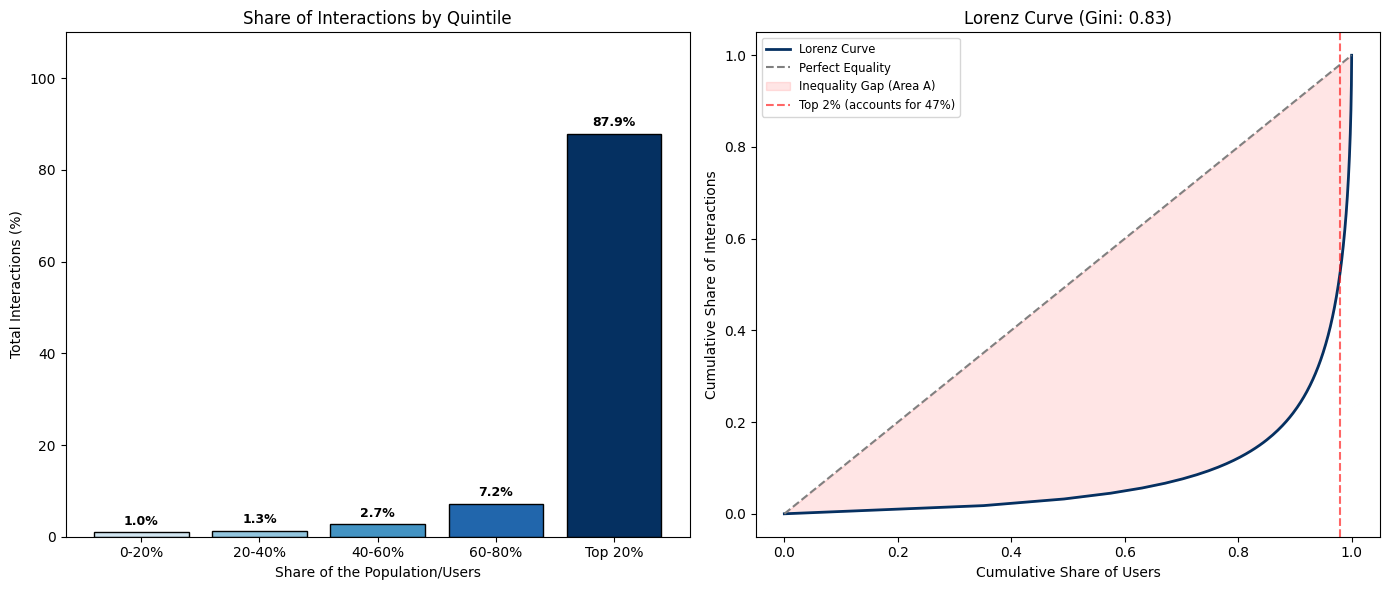

In [79]:
y_sorted = np.sort(df_author_interaction["interaction_per_user"].to_numpy())
total_val = y_sorted.sum()
n_users = len(y_sorted)

# lorenz data
cum_users = np.arange(1, n_users + 1) / n_users
cum_activity = np.cumsum(y_sorted) / total_val
gini = 1 - 2 * np.sum((cum_activity[1:] + cum_activity[:-1]) * np.diff(cum_users) / 2)

# quintile data
groups = np.array_split(y_sorted, 5)
shares = [(g.sum() / total_val) * 100 for g in groups]
quintile_labels = ['0-20%', '20-40%', '40-60%', '60-80%', 'Top 20%']
colors = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Quintile Bar Chart
bars = ax1.bar(quintile_labels, shares, color=colors, edgecolor='black')
ax1.set_title('Share of Interactions by Quintile')
ax1.set_ylabel('Total Interactions (%)')
ax1.set_xlabel('Share of the Population/Users')
ax1.set_ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Lorenz Curve
ax2.plot(cum_users, cum_activity, label='Lorenz Curve', color='#053061', linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect Equality')
ax2.fill_between(cum_users, cum_activity, cum_users, color='red', alpha=0.1, label='Inequality Gap (Area A)')

# threshold 
ax2.axvline(cum_users[int(len(y_sorted) * 0.98)], linestyle='--', color='r', alpha=0.6, label=f'Top 2% (accounts for {(1-cum_activity[int(len(y_sorted) * 0.98)])*100:.0f}%)')
ax2.set_title(f'Lorenz Curve (Gini: {gini:.2f})')
ax2.set_xlabel('Cumulative Share of Users')
ax2.set_ylabel('Cumulative Share of Interactions')
ax2.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

#### 98th Percentile vs. Power-law xmin

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 4101/4101 [06:13<00:00, 10.98it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Top 2% threshold: 185.00
Power-law xmin: 622.00


/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_13585/1656712637.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


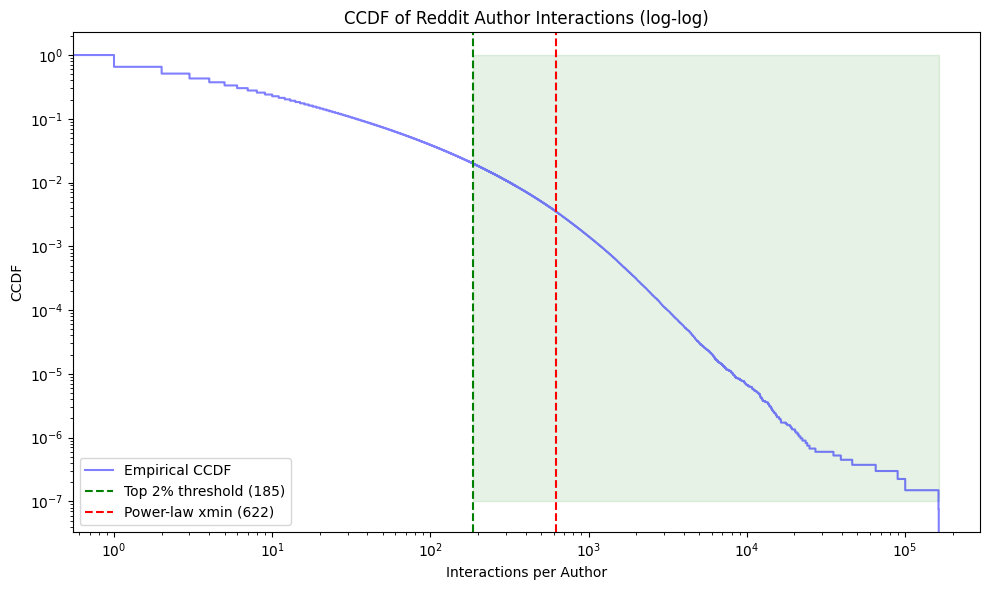

In [80]:
# Data
data = df_author_interaction["interaction_per_user"].to_numpy()

# Compute thresholds
# 98th percentile
threshold_2pct = np.percentile(data, 98)

# Power law params
fit = powerlaw.Fit(data) 
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Top 2% threshold: {threshold_2pct:.2f}")
print(f"Power-law xmin: {xmin:.2f}")

# Compute ECDF and CCDF
ecdf = ECDF(data)
ccdf = 1 - ecdf.y  # CCDF = 1 - CDF

# plot CCDF
plt.figure(figsize=(10,6))
plt.step(ecdf.x, ccdf, where='post', color='blue', alpha=0.5, label='Empirical CCDF')
plt.xscale('log')  # log-log scale
plt.yscale('log')

# threshold lines
plt.axvline(threshold_2pct, color='green', linestyle='--',  
            label=f'Top 2% threshold ({threshold_2pct:.0f})')
plt.axvline(xmin, color='red', linestyle='--',
            label=f'Power-law xmin ({xmin:.0f})')

# shade the top 2%
plt.fill_betweenx(y=[1e-7, 1], x1=threshold_2pct, x2=ecdf.x.max(),
                  color='green', alpha=0.1)

# labels
plt.xlabel("Interactions per Author")
plt.ylabel("CCDF")
plt.title("CCDF of Reddit Author Interactions (log-log)")
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Compare Power Law vs. Log-normal
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Loglikelihood ratio (R): {R:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    if R > 0:
        print("Conclusion: Reject H0. Power Law is a significantly better fit.")
    else:
        print("Conclusion: Reject H0. Log-normal is a significantly better fit.")
else:
    print("Conclusion: Fail to reject H0. Neither distribution is significantly better.")

Loglikelihood ratio (R): -198.21
p-value: 0.0000
Conclusion: Reject H0. Log-normal is a significantly better fit.


Log-normal parameters: mu=3.15, sigma=1.45


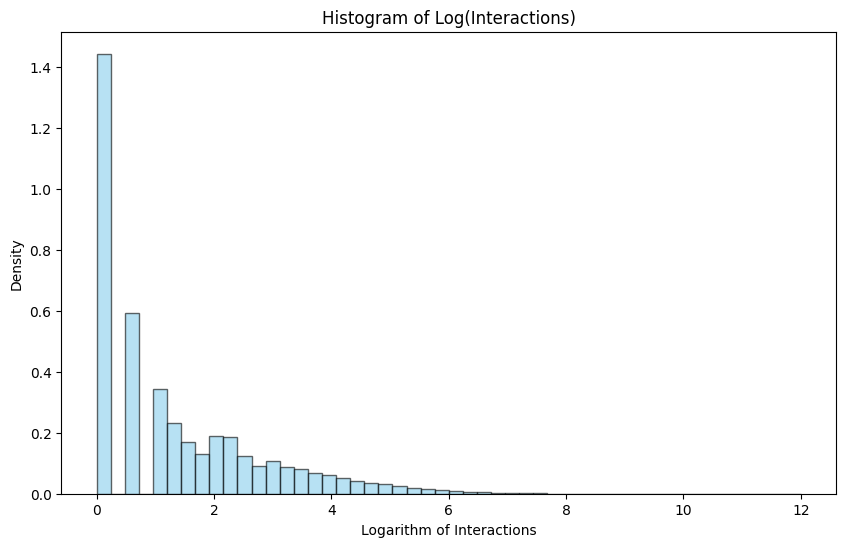

In [15]:
# Extract parameters from the fit
mu = fit.lognormal.mu
sigma = fit.lognormal.sigma

print(f"Log-normal parameters: mu={mu:.2f}, sigma={sigma:.2f}")

# Verification: Plot the histogram of the LOG of the data
log_data = np.log(data[data > 0])
plt.figure(figsize=(10, 6))
plt.hist(log_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histogram of Log(Interactions)')
plt.xlabel('Logarithm of Interactions')
plt.ylabel('Density')
plt.show()

## Section 3: Data Filtration

#### 3.1 Detecting Hyperactive Users (bots or anamalous values)

In [16]:
# get the top 2% df to detect bots and extreme users

threshold_filter = df_author_interaction.select(pl.col('interaction_per_user').quantile(0.98)).item()

df_top_users = df_author_interaction.filter(
    pl.col('interaction_per_user') > threshold_filter).select('author')

display(df_top_users)
print(f'98th Percentile: {threshold_filter}')

author
str
"""donut-bot"""
"""TipOfTheirTongue"""
"""VisualMod"""
"""MinecraftModBot"""
"""MrPuma86"""
…
"""transmogisadumbitch"""
"""HopDropNRoll"""
"""Broadway_Nerdd"""


98th Percentile: 185.0


In [17]:
# sanity check 
top_users_count = df_top_users.height
total_users = df_author_interaction.height
pct = top_users_count / total_users
print(f'{pct:.4f}')

0.0200


In [18]:
# remove top 2%

auti_wo_top = df_author_interaction.join(
    df_top_users,
    on='author',
    how='anti').sort('rank', descending=False)

auti_wo_top

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""BuddyJustBuddy""",1,13361404
"""fishstickburner""",1,13361405
"""iMerlin23""",1,13361406


In [33]:
# display reconciled without hyperactive users

df_all_wo_top = df_all.join(
    auti_wo_top.select("author"),
    on="author",
    how="inner"
)

display(df_all_wo_top)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
"""One-Personality3513""","""houseofthedragon""",2,1,3
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


#### 3.2 Detecting Inactive Users

#### Frequency Distribution Table

In [20]:
# number of users for each interaction_per_user (least active to most active)

interaction_per_user_count = (
    auti_wo_top.group_by("interaction_per_user")
    .len()
    .rename({"len": "user_count"})
    .sort("interaction_per_user")
)

interaction_per_user_count = interaction_per_user_count.with_columns((
    (pl.col('user_count') / pl.col('user_count').sum()) * 100).alias('pct (%)'))

interaction_per_user_count.head(10)

interaction_per_user,user_count,pct (%)
i64,u32,f64
1,4627336,35.337481
2,1896163,14.480389
3,1099410,8.395841
4,739755,5.649272
5,539538,4.120279
6,414583,3.166037
7,331496,2.531529
8,271888,2.076321
9,228556,1.745409


#### Head–Tail Breaks for Identifying Inactive Users

To identify inactive Reddit users, the **Head–Tail Breaks (HTB)** algorithm [(Jiang et al., 2013)](https://arxiv.org/abs/1102.1561) was applied to the distribution of total user interactions (`interaction_per_user`). HTB is designed for **heavy-tailed distributions**, where many observations are small and a small minority are large, a pattern pervasive in online participation data.

The method partitions the distribution around the **mean value** into:

- **Head:** values greater than the mean  
- **Tail:** values less than or equal to the mean  

The weighted mean is computed as:

$$
\mu = \frac{\sum (x_i f_i)}{\sum f_i}
$$

where $x_i$ is the number of interactions and $f_i$ is the number of users with that interaction count.

In our case, only the **first HTB iteration** was used to identify the initial separation between low-activity and more active users. Users with interaction counts **below the first mean threshold** were classified as inactive and removed.

Using HTB renders a **data-driven threshold** for filtering minimally active or “drive-by” users, reducing noise and sparsity before constructing the **user–subreddit incidence matrix**.

In [68]:
# head-tail breaks algorithm 

def find_head_tail_break(data):
    current_data = data  # interaction_per_user = value (X)
    iteration = 1    # user_count = frequency (Y)
    
    while True:
        # get weighted mean: (value * frequency) / total frequency
        total_val = (current_data["interaction_per_user"] * current_data["user_count"]).sum()
        total_freq = current_data["user_count"].sum()
        mu = total_val / total_freq
        
        # head = those strictly above the mean
        head = current_data.filter(pl.col("interaction_per_user") > mu)
        
        # calculate percentage of users remaining in head
        head_percentage = head["user_count"].sum() / total_freq
        
        print(f"Iteration {iteration}: Mean = {mu:.2f}, Head % = {head_percentage:.2%}")
        
        # If the head is no longer a small minority (<40%), 
        # or we run out of data, the current mean is our natural threshold.
        if head_percentage > 0.40 or head.height == 0:
            final_threshold = round(mu)
            print(f"\nRESULT")
            print(f"Natural Mathematical Threshold: {final_threshold}")
            return final_threshold
            
        current_data = head
        iteration += 1

# Execute
final_threshold = find_head_tail_break(interaction_per_user_count)

Iteration 1: Mean = 10.78, Head % = 21.00%
Iteration 2: Mean = 41.01, Head % = 31.76%
Iteration 3: Mean = 84.52, Head % = 39.71%
Iteration 4: Mean = 123.40, Head % = 44.17%

RESULT
Natural Mathematical Threshold: 123


In [45]:
# implement head-tail algo using mapclassify lib (sanity check)

interaction_per_user = auti_wo_top["interaction_per_user"].to_numpy()
htb = mapclassify.HeadTailBreaks(interaction_per_user)
count = htb.counts
bins = htb.bins

df_htb = pd.DataFrame({'count (users)': count,
                       'bins (upper bound)': np.round(bins, 2)})

df_htb['class'] = pd.Series(np.arange(1, 13))
df_htb = df_htb[['class', 'count (users)', 'bins (upper bound)']]
df_htb = df_htb.set_index('class')
display(df_htb)

low_activity_thres = df_htb['bins (upper bound)'][1]
print(f'Remove inactive users/first class: < {low_activity_thres:.0f}')
# interpretation: 
# class 1 - Users with interaction_per_user ≤ 10.78 → 10,344,424 users
# class 2 → 10.78 < users ≤ 41.01 → low activity
# class 3 → 41.01 < users ≤ 84.52 → medium activity
# class 4 → 84.52 < users ≤ 123.40 → head (active)

,count (users),bins (upper bound)
class,,
1,10344424,10.78
2,1876882,41.01
3,526589,84.52
4,193626,123.40
5,80868,150.66
6,36556,166.87
7,17659,175.71
8,9373,180.39
9,3599,182.96


Remove inactive users/first class: < 11


In [46]:
# get initially cleaned df without hyperactive ones to filter out inactive ones 
# threshold = > 10 interactions

auti_cleaned = auti_wo_top.filter(pl.col('interaction_per_user') > low_activity_thres)
auti_cleaned

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""SomeoneAwesome11""",11,3016980
"""Tiny-Necessary4298""",11,3016981
"""Abhiabhiii""",11,3016982


In [47]:
# display reconciled without hyperactive users

df_all_wo_topnbot = df_all_wo_top.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
).sort('interaction_count', descending=False)

display(df_all_wo_topnbot)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Japparbyn""","""interestingasfuck""",0,1,1
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Chumbief""","""abandonedporn""",0,1,1
"""CozyOdyssey""","""rarepuppers""",0,1,1
"""chappyfu""","""funny""",0,1,1
…,…,…,…,…
"""Regulith""","""destinythegame""",1,184,185
"""Elsweyrwarrior""","""pokemon""",1,184,185
"""dryland305""","""gardening""",2,183,185


### 3.3 Cleaned `user_subreddit_interactions`

In [48]:
# clean df_all (remove top users)

clean_df_all = df_all.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
)

display(clean_df_all)

print("\nSummary:")

print("\nHyperactive Filtration:")
print("Before Removing Hyperactive Users (Top 2%):", df_all.height, "rows")
print("After Removing Hyperactive Users (Top 2%):", df_all_wo_top.height, "rows")
print("No. of Rows Removed (Hyperactive Active Users):", df_all.height - df_all_wo_top.height, "rows")
print(f"Percentage of Rows Removed: {((df_all.height - df_all_wo_top.height)/df_all.height)*100:.2f}%")

print("\nInactive Filtration:")
print("Before Removing Inactive Users (interaction_count < 11):", df_all_wo_top.height, "rows")
print("After Removing  Inactive Users (interaction_count < 11):", df_all_wo_topnbot.height, "rows")
print("No. of Rows Removed (Inactive Users):", df_all_wo_top.height - df_all_wo_topnbot.height, "rows")
print(f"Percentage of Rows Removed: {((df_all_wo_top.height - df_all_wo_topnbot.height)/df_all_wo_top.height)*100:.2f}%")

print('\nTotal:')
print(f"Total Rows Removed: {df_all.height - clean_df_all.height} rows")
print(f"Percentage of Rows Removed: {((df_all.height - clean_df_all.height)/df_all.height)*100:.2f}%")

# 2% of users contributed 14.43% of the total interactions, which is exactly what the long-tail dist shows, hence the need
# to remove them

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BeyondStars_ThenMore""","""facepalm""",0,7,7
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Ok-Protection-1214""","""bollyblindsngossip""",8,25,33
…,…,…,…,…
"""FoxDays""","""starwars""",3,0,3
"""SpruceBingsteen""","""beamazed""",0,1,1
"""spoonyF0rky01""","""news""",0,6,6



Summary:

Hyperactive Filtration:
Before Removing Hyperactive Users (Top 2%): 46724134 rows
After Removing Hyperactive Users (Top 2%): 39981748 rows
No. of Rows Removed (Hyperactive Active Users): 6742386 rows
Percentage of Rows Removed: 14.43%

Inactive Filtration:
Before Removing Inactive Users (interaction_count < 11): 39981748 rows
After Removing  Inactive Users (interaction_count < 11): 22884988 rows
No. of Rows Removed (Inactive Users): 17096760 rows
Percentage of Rows Removed: 42.76%

Total:
Total Rows Removed: 23839146 rows
Percentage of Rows Removed: 51.02%


In [145]:
# save to analytics/parquet
clean_df_all.write_parquet("analytics/clean_df_all.parquet")

## Section 3: Matrices

| Feature | Bipartite Matrix ($B$) | Adjacency Matrix ($B^T B$) |
| :--- | :--- | :--- |
| **Shape** | **Rectangular** (Authors $\times$ Subreddits) | **Square** (Subreddits $\times$ Subreddits) |
| **Relationship** | "Who posted where?" | "Which subreddits are similar?" |
| **Data Type** | Raw interactions (Direct/Interaction Count) | Derived connections (Shared users) |
| **Dimensions** | $2,750,273 \times 501$ | $500 \times 500$ |

#### 3.1 User-Subreddit Matrix (Incidence Matrix)

In [172]:
# Bipartite Matrix (Bi-adjacency matrix) is a matrix that represents relationships between two 
# distinct types of entities (authors and subreddit)
# connections only happen between different groups never within the same group
# Author => subreddit, author !=> author, subreddit !=> subreddit (unlike adjacency matrix)

incidence_matrix = clean_df_all.pivot("subreddit", 
                                      index='author',
                                      values='interaction_count')

incidence_matrix = incidence_matrix.fill_null(0)
incidence_matrix

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### 3.2 Clean Incidence Matrix (Ensure Non-Zero Columns)

In [69]:
# keep cols that have at least one non-zero value

# compute sums for all columns except 'author'
col_sums = incidence_matrix.drop("author").select([
    pl.sum(col).alias(col) for col in incidence_matrix.drop("author").columns
]).to_dicts()[0]

cols_to_keep = ["author"] + [col for col, total in col_sums.items() if total > 0]
cleaned_incidence_matrix = incidence_matrix.select(cols_to_keep)
cleaned_incidence_matrix

# no col was dropped

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [161]:
# drop authors
print(cleaned_incidence_matrix.dtypes)
numeric_matrix = cleaned_incidence_matrix.drop("author") # drop author to enable computation

[String, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int6

In [162]:
# comvert from dataframe to sparse matrix (csr_matrix)
# In a Sparse Matrix (CSR), the computer doesn't store a grid; it stores a list of coordinates for every value
B = csr_matrix(numeric_matrix )
print(B[:5, :10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (5, 10)>
  Coords	Values
  (0, 0)	16
  (1, 0)	11
  (1, 1)	1
  (1, 2)	28
  (1, 3)	1
  (2, 2)	7
  (3, 0)	1
  (3, 2)	1
  (3, 3)	1
  (3, 6)	1
  (4, 4)	33


In [160]:
# snippet first 5 rows then first 10 cols
print(B[:5, :10].toarray())

[[16  0  0  0  0  0  0  0  0  0]
 [11  1 28  1  0  0  0  0  0  0]
 [ 0  0  7  0  0  0  0  0  0  0]
 [ 1  0  1  1  0  0  1  0  0  0]
 [ 0  0  0  0 33  0  0  0  0  0]]


#### 3.3 Compute Subreddit Adjacency Matrix (Co-occurrence Matrix)

In [183]:
# Adjacency Matrix is a mathematical map that shows how every subreddit in the list is connected to 
# every other subreddit based on shared/overlapping authors (bridges).
# square matrix where both the rows and the columns represent the same set of items

# (500 x 2,750,273) x (2,750,273 x 500) -> (500 x 500) matrix
# In graph theory, two things are adjacent if there is a direct link (edge) between them (https://workforce.libretexts.org/Bookshelves/Construction/Building_Information_-_Representation_and_Management_Principles_and_Foundations_for_the_Digital_Era_(Koutamanis)/06%3A_Appendices/6.01%3A_Appendix_I-_Graph_theory)
adjacency_matrix = B.T @ B

# Remove Self-Loops -> the diags are sum of squares of a subreddit’s own activity
# if an adjacency matrix shows how subreddits are connected via number of shared users,
# then the diags are js the square of a subreddit (100% related to itself) so need to be eliminated 
# set to 0 cuz we're only concerned about external connections
adjacency_matrix.setdiag(0)

# removes the 0s from the memory of the 
# sparse matrix(meaning the matrix that stores the values through coordinates or index of row, col)
# it doesn't store it so if a computer does not see (0, 0) or coordinates, it assumes = 0
adjacency_matrix.eliminate_zeros()
print(adjacency_matrix[:3, :3])
print(adjacency_matrix[:3, :3].toarray())

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 6 stored elements and shape (3, 3)>
  Coords	Values
  (2, 0)	403264
  (1, 0)	157345
  (2, 1)	3684072
  (0, 1)	157345
  (1, 2)	3684072
  (0, 2)	403264
[[      0  157345  403264]
 [ 157345       0 3684072]
 [ 403264 3684072       0]]


#### 3.4 No. of Non-Zero Values (Actual Connections)

In [175]:
# number of non-zeros/edges or subreddit connections
print(adjacency_matrix.nnz)

# 248,250, it means out of 250,000 possible relationships, only 2,751 pairs of subreddits have zero shared authors.
# Every other pair has at least one person in common.

248250


#### 3.5 Handling Single-Interaction Subreddit Pairs

In [176]:
# Remove single-interaction subreddit pairs - from [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/)
adjacency_matrix.data[adjacency_matrix.data == 1] = 0
adjacency_matrix.eliminate_zeros()
adjacency_matrix

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 247698 stored elements and shape (500, 500)>

#### 3.6 Density

In [185]:
# density 

# N = number of subreddits (500)
N = adjacency_matrix.shape[0] 

# total potential/possible
total_possible = N * N

# actual connections
actual_connections = adjacency_matrix.nnz

# density formula
density = actual_connections / total_possible

print(f"Network Density: {density:.4f}")
print(f"Density Percentage: {density:.2%}")

Network Density: 0.9930
Density Percentage: 99.30%


In [186]:
# Calculate what the 90th percentile weight is
top_10_percent_cutoff = np.percentile(adjacency_matrix.data, 90)

print(f"To keep only the top 10% of edges, threshold should be: {top_10_percent_cutoff}")

To keep only the top 10% of edges, threshold should be: 36789.0


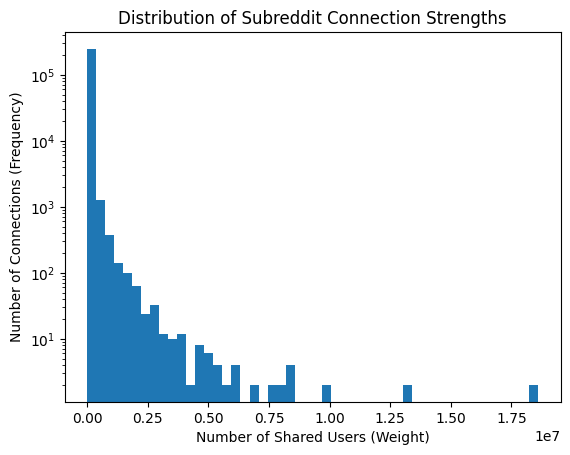

In [187]:
import matplotlib.pyplot as plt

# Plot a histogram of the weights (log scale helps because the numbers are so big)
plt.hist(adjacency_matrix.data, bins=50, log=True)
plt.xlabel('Number of Shared Users (Weight)')
plt.ylabel('Number of Connections (Frequency)')
plt.title('Distribution of Subreddit Connection Strengths')
plt.show()

In [188]:
# We want to keep about 10,000 edges for a clean visualization
target_edges = 10000
total_edges = len(adjacency_matrix.data)
percentile_to_keep = (target_edges / total_edges) * 100

# This finds the threshold to leave you with exactly ~10,000 edges
dynamic_threshold = np.percentile(adjacency_matrix.data, 100 - percentile_to_keep)

print(f"To get a clean graph with {target_edges} edges,")
print(f"you should use a threshold of: {dynamic_threshold:.2f}")

To get a clean graph with 10000 edges,
you should use a threshold of: 97031.13


In [191]:
# Apply the 97k threshold temporarily
temp_matrix = adjacency_matrix.copy()
temp_matrix.data[temp_matrix.data < 97031] = 0
temp_matrix.eliminate_zeros()

# Count how many subreddits still have at least one connection
connected_count = (temp_matrix.getnnz(axis=1) > 0).sum()
isolated_count = 500 - connected_count

print(f"Subreddits with connections: {connected_count}")
print(f"Subreddits now isolated (0 connections): {isolated_count}")

Subreddits with connections: 393
Subreddits now isolated (0 connections): 107


In [233]:
import numpy as np
from scipy import sparse

# 1. Use your 500x500 filtered matrix (with the 0 diagonal)
W = adjacency_matrix.tocoo().astype(np.float64)

# 2. Estimate Subreddit Size (The "Proxy")
# We take the maximum overlap any subreddit has as its 'estimated size'
subreddit_sizes = np.array(adjacency_matrix.max(axis=1).todense()).flatten()

# 3. Safe Jaccard Calculation
rows = W.row
cols = W.col
intersection = W.data

# Union = Size A + Size B - Intersection
union = subreddit_sizes[rows] + subreddit_sizes[cols] - intersection

# Avoid division by zero/negatives (safety first)
jaccard_values = np.where(union > 0, intersection / union, 0)

# 4. Create the Research-Grade Matrix
jaccard_matrix = sparse.csr_matrix((jaccard_values, (rows, cols)), shape=(500, 500))

# 5. Set self-similarity to 1.0
jaccard_matrix.setdiag(1.0)

print(f"Success! Max Weight: {jaccard_matrix.data.max():.2f}")

Success! Max Weight: 1.00


In [234]:
import networkx as nx
from networkx.algorithms import community

# 1. Create the Graph from your Research-Grade Jaccard Matrix
# Weight=True ensures the algorithm respects your Jaccard scores
G_final = nx.from_scipy_sparse_array(jaccard_matrix, edge_attribute='weight')

# 2. Run Louvain Community Detection
# This finds the "Modularity" – groups that are more connected to 
# each other than they are to the rest of the network.
clusters = community.louvain_communities(G_final, weight='weight', seed=42)

# 3. Sort them by size to see the "Big Players"
clusters = sorted(clusters, key=len, reverse=True)

print(f"Detected {len(clusters)} distinct communities.")
for i, cluster in enumerate(clusters[:5]): # Show top 5
    print(f"Community {i+1} Size: {len(cluster)} subreddits")

Detected 33 distinct communities.
Community 1 Size: 67 subreddits
Community 2 Size: 59 subreddits
Community 3 Size: 47 subreddits
Community 4 Size: 43 subreddits
Community 5 Size: 26 subreddits


In [235]:
# 1. Calculate Eigenvector Centrality (takes weights into account)
centrality = nx.eigenvector_centrality(G_final, weight='weight')

# 2. Print the top subreddit for each of your clusters
print("--- Community Leaders (Capitals) ---")
for i, cluster in enumerate(clusters[:5]):
    # Find the node in this cluster with the highest centrality score
    leader_node = max(cluster, key=lambda node: centrality[node])
    leader_name = subreddit_list[leader_node] 
    
    print(f"Community {i+1} Leader: r/{leader_name} (Size: {len(cluster)})")

--- Community Leaders (Capitals) ---
Community 1 Leader: r/formula1 (Size: 67)
Community 2 Leader: r/freeebooks (Size: 59)
Community 3 Leader: r/popculturechat (Size: 47)
Community 4 Leader: r/bollyblindsngossip (Size: 43)
Community 5 Leader: r/buyitforlife (Size: 26)


In [236]:
# Calculate Betweenness Centrality
# High score = this subreddit sits on the paths between different tribes
betweenness = nx.betweenness_centrality(G_final, weight='weight')

# Get the top 10 bridges
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("--- The Bridge Subreddits (Diplomats) ---")
for node_idx, score in top_bridges:
    print(f"r/{subreddit_list[node_idx]}: {score:.4f}")

--- The Bridge Subreddits (Diplomats) ---
r/softwaregore: 0.4732
r/jokes: 0.3258
r/gamedev: 0.2684
r/dataisbeautiful: 0.2676
r/mma: 0.2625
r/android: 0.2012
r/youtubehaiku: 0.1674
r/programmerhumor: 0.1559
r/perfectlycutscreams: 0.1352
r/aitah: 0.0831


In [265]:
# import matplotlib.pyplot as plt
# import networkx as nx

# # 1. Map each node to its community ID for coloring
# # G_final is your Jaccard-weighted graph
# node_to_community = {}
# for i, community_set in enumerate(clusters):
#     for node in community_set:
#         node_to_community[node] = i

# # 2. Extract colors and sizes (Eigenvector Centrality for node scale)
# colors = [node_to_community[node] for node in G_final.nodes()]
# centrality = nx.eigenvector_centrality(G_final, weight='weight')
# node_sizes = [centrality[node] * 5000 for node in G_final.nodes()] # Scale for visibility

# # 3. Choose a layout (Spring layout is standard for community visibility)
# pos = nx.spring_layout(G_final, k=0.15, seed=42, iterations=50)

# # 4. Draw
# plt.figure(figsize=(15, 15))

# # Draw edges with very low alpha to prevent the "Hairball" effect
# nx.draw_networkx_edges(G_final, pos, alpha=0.05, edge_color='gray')

# # Draw nodes with the community colors
# nx.draw_networkx_nodes(G_final, pos, 
#                        node_color=colors, 
#                        node_size=node_sizes, 
#                        cmap=plt.cm.tab20b, 
#                        alpha=0.9)

# # 5. Label ONLY the 5 Capital Subreddits
# capitals = [
#     "formula1", "freeebooks", "popculturechat", 
#     "bollyblindsngossip", "buyitforlife"
# ]

# # Find the node indices for these names in your subreddit_list
# capital_labels = {}
# for i, name in enumerate(subreddit_list):
#     if name in capitals:
#         capital_labels[i] = f"r/{name}"

# nx.draw_networkx_labels(G_final, pos, labels=capital_labels, 
#                         font_size=12, font_weight='bold')

# plt.title("Map of 33 Reddit Tribes (Jaccard-Normalized)", fontsize=20)
# plt.axis('off')
# plt.show()

In [264]:
# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# from scipy import sparse
# from networkx.algorithms import community

# # --- STEP 1: JACCARD NORMALIZATION (The "Research-Grade" Matrix) ---
# # We use the row-maximum as a proxy for subreddit size since the diagonal is 0
# W = adjacency_matrix.tocoo().astype(np.float64)
# subreddit_sizes = np.array(adjacency_matrix.max(axis=1).todense()).flatten()

# rows = W.row
# cols = W.col
# intersection = W.data

# # Union = Size A + Size B - Intersection
# union = subreddit_sizes[rows] + subreddit_sizes[cols] - intersection

# # Calculate weights where union > 0 to avoid division errors
# jaccard_values = np.where(union > 0, intersection / union, 0)

# # Reconstruct the 500x500 normalized matrix
# jaccard_matrix = sparse.csr_matrix((jaccard_values, (rows, cols)), shape=(500, 500))
# jaccard_matrix.setdiag(1.0) # A sub is 100% similar to itself

# # --- STEP 2: GRAPH BUILDING & COMMUNITY DETECTION ---
# # Create graph and keep weights for the algorithm
# G = nx.from_scipy_sparse_array(jaccard_matrix, edge_attribute='weight')

# # Run Louvain (requires weight='weight' to use Jaccard scores)
# clusters = community.louvain_communities(G, weight='weight', seed=42)
# clusters = sorted(clusters, key=len, reverse=True) # Sort by tribe size

# # --- STEP 3: CENTRALITY & CAPITAL IDENTIFICATION ---
# # Eigenvector Centrality finds the "influencers" within the groups
# centrality = nx.eigenvector_centrality(G, weight='weight')

# # Map each node to its community ID for coloring
# node_to_community = {}
# for i, community_set in enumerate(clusters):
#     for node in community_set:
#         node_to_community[node] = i

# # --- STEP 4: VISUALIZATION PREPARATION ---
# node_order = list(G.nodes())
# node_colors = [node_to_community[n] for n in node_order]
# # Scaling sizes: Centrality scores are small (0-1), so we amplify them
# node_sizes = [centrality[n] * 5000 for n in node_order]

# # Use Spring Layout (k controls the distance between nodes)
# pos = nx.spring_layout(G, k=0.18, seed=42)

# # --- STEP 5: DRAWING THE MAP ---
# plt.figure(figsize=(16, 12))

# # 1. Draw Edges (Roads) - Low alpha to hide the hairball
# nx.draw_networkx_edges(G, pos, alpha=0.03, edge_color='gray', width=0.5)

# # 2. Draw Nodes (Cities)
# nx.draw_networkx_nodes(G, pos, 
#                        node_size=node_sizes, 
#                        node_color=node_colors, 
#                        cmap=plt.cm.tab20b, 
#                        alpha=0.8)

# # 3. Label your 5 specific Capital Subreddits
# # Assuming subreddit_list contains your 500 names in order
# capitals_to_label = ["formula1", "freeebooks", "popculturechat", 
#                      "bollyblindsngossip", "buyitforlife"]

# labels = {}
# for i, name in enumerate(subreddit_list):
#     if name in capitals_to_label:
#         labels[i] = f"r/{name}"

# nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight='bold')

# plt.title(f"Reddit Atlas: {len(clusters)} Communities Identified", fontsize=18)
# plt.axis('off')
# plt.show()

# # --- STEP 6: PRINT SUMMARY ---
# print(f"Total Tribes: {len(clusters)}")
# for i, cluster in enumerate(clusters[:5]):
#     leader_node = max(cluster, key=lambda n: centrality[n])
#     print(f"Tribe {i+1} Leader: r/{subreddit_list[leader_node]} (Size: {len(cluster)})")

In [242]:
# 1. Make a copy of your Jaccard matrix
pruned_jaccard = jaccard_matrix.copy()

# 2. Set the threshold (Try 0.05 first - means 5% shared audience)
# Any connection weaker than this is likely noise
threshold = 0.05 
pruned_jaccard.data[pruned_jaccard.data < threshold] = 0
pruned_jaccard.eliminate_zeros()

# 3. Remove the diagonal (Self-loops make the layout messy)
pruned_jaccard.setdiag(0)
pruned_jaccard.eliminate_zeros()

# 4. Create the new graph
G_final = nx.from_scipy_sparse_array(pruned_jaccard, edge_attribute='weight')

# 5. Remove 'Isolates' (Nodes with 0 edges after pruning)
# This cleans up the "floating dots" on the outside
G_final.remove_nodes_from(list(nx.isolates(G_final)))

print(f"Edges remaining: {G_final.number_of_edges()}")
print(f"Nodes remaining: {G_final.number_of_nodes()}")

Edges remaining: 2063
Nodes remaining: 418


In [263]:
# # 1. Re-run Louvain on the CLEANED graph
# # This will find much sharper, more meaningful communities
# clusters = community.louvain_communities(G_final, weight='weight', seed=42)
# clusters = sorted(clusters, key=len, reverse=True)

# # 2. Map colors
# node_to_community = {}
# for i, community_set in enumerate(clusters):
#     for node in community_set:
#         node_to_community[node] = i

# # 3. Calculate Layout
# # k=0.5 or higher will push clusters further apart for better visibility
# pos = nx.spring_layout(G_final, k=0.6, iterations=100, seed=42)

# # 4. Draw the Atlas
# plt.figure(figsize=(16, 12))

# # Nodes colored by their NEW, PRUNED tribes
# nx.draw_networkx_nodes(G_final, pos, 
#                        node_size=100, 
#                        node_color=[node_to_community[n] for n in G_final.nodes()], 
#                        cmap=plt.cm.tab20, 
#                        alpha=0.9)

# # Edges: Only the strong connections remain
# nx.draw_networkx_edges(G_final, pos, alpha=0.2, edge_color='black', width=1)

# # Label only the Capitals (using the names you found earlier)
# capitals = ["formula1", "freeebooks", "popculturechat", "bollyblindsngossip", "buyitforlife"]
# labels = {i: f"r/{name}" for i, name in enumerate(subreddit_list) if name in capitals and i in G_final}

# nx.draw_networkx_labels(G_final, pos, labels=labels, font_size=12, font_weight='bold')

# plt.title(f"Reddit Social Map: {len(clusters)} Tribes (Threshold 0.05)", fontsize=18)
# plt.show()

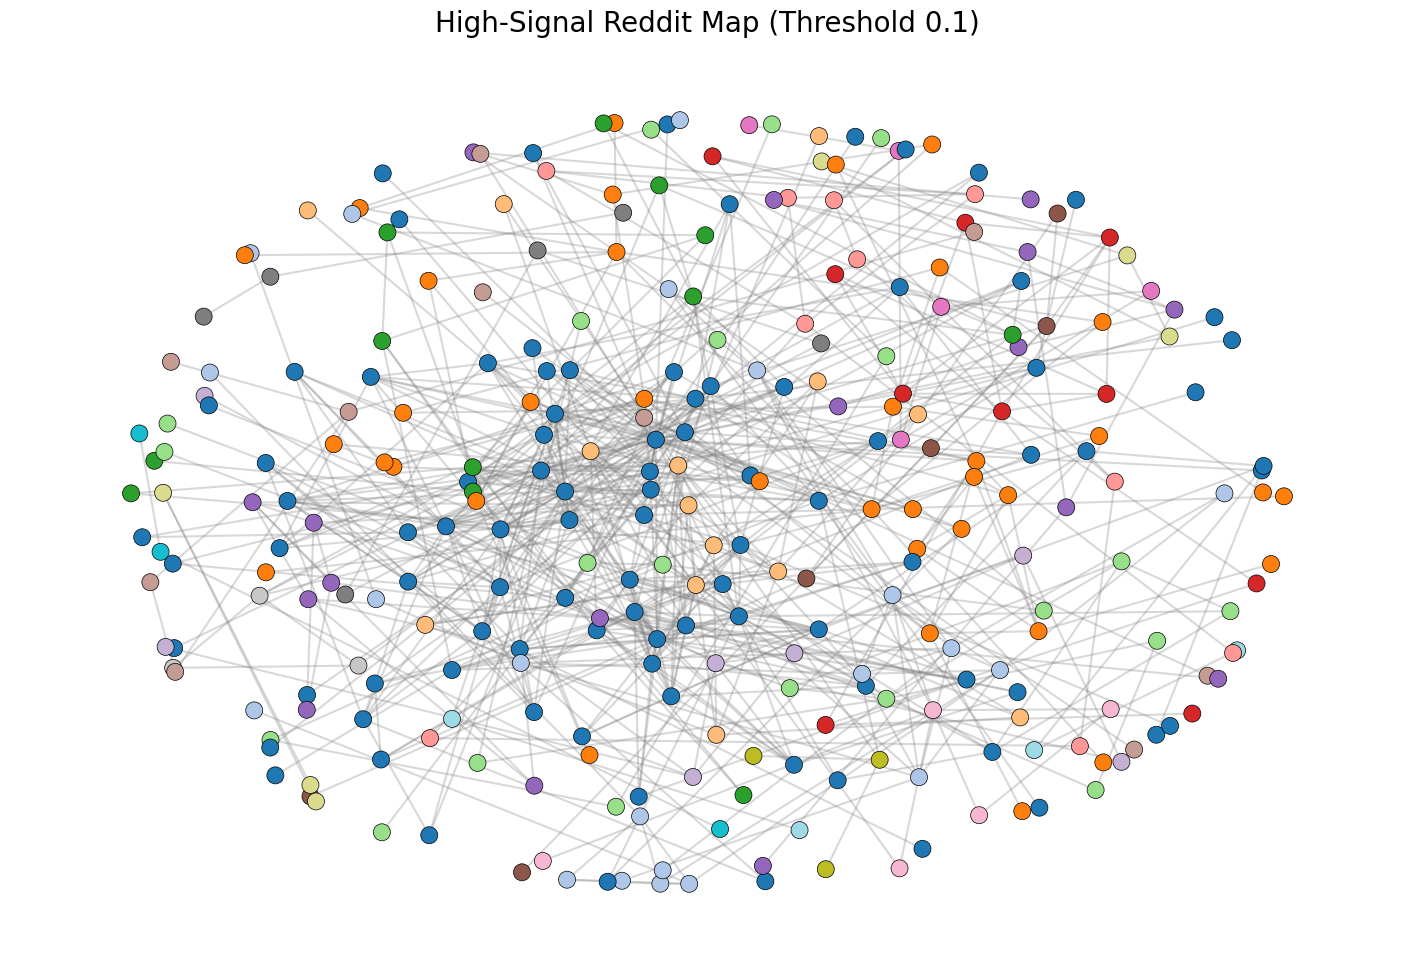

Nodes: 292 | Edges: 670


In [255]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Increase Threshold to 0.10 (10% similarity)
threshold = 0.10 
pruned_matrix = jaccard_matrix.copy()
pruned_matrix.data[pruned_matrix.data < threshold] = 0
pruned_matrix.eliminate_zeros()

# 2. Build the graph
G_high_sig = nx.from_scipy_sparse_array(pruned_matrix, edge_attribute='weight')
G_high_sig.remove_edges_from(nx.selfloop_edges(G_high_sig))

# 3. Clean-up: Remove isolates AND small "noise" clusters
# This focuses the map only on communities of 3 or more subreddits
G_high_sig.remove_nodes_from(list(nx.isolates(G_high_sig)))

# Optional: Remove tiny "duos" to focus on larger trends
for component in list(nx.connected_components(G_high_sig)):
    if len(component) < 3:
        G_high_sig.remove_nodes_from(component)

# 4. Re-run Louvain on this high-signal data
clusters = sorted(nx.community.louvain_communities(G_high_sig, weight='weight', seed=42), key=len, reverse=True)

# 5. Visualization with "Exploded" Layout
# Increased k (0.8) and iterations (150) forces more separation
pos = nx.spring_layout(G_high_sig, k=0.8, iterations=150, seed=42)

plt.figure(figsize=(18, 12))
node_colors = [next(i for i, c in enumerate(clusters) if n in c) for n in G_high_sig.nodes()]

# Draw edges thicker to show "Heavy Traffic" routes
nx.draw_networkx_edges(G_high_sig, pos, alpha=0.3, edge_color='gray', width=1.5)

# Draw nodes
nx.draw_networkx_nodes(G_high_sig, pos, 
                       node_size=150, 
                       node_color=node_colors, 
                       cmap=plt.cm.tab20, 
                       edgecolors='black', linewidths=0.5)

# Label the 5 Capitals
# labels = {i: f"r/{name}" for i, name in enumerate(subreddit_list) 
#           if name in capitals and i in G_high_sig}

nx.draw_networkx_labels(G_high_sig, pos, labels={}) # labels=labels, font_size=14, font_weight='bold'

plt.title(f"High-Signal Reddit Map (Threshold {threshold})", fontsize=20)
plt.axis('off')
plt.show()

print(f"Nodes: {G_high_sig.number_of_nodes()} | Edges: {G_high_sig.number_of_edges()}")

In [258]:
# Create a dictionary to hold our report
tribe_report = []

for i, cluster in enumerate(clusters):
    # Get names of subreddits in this cluster
    names = [subreddit_list[node] for node in cluster]
    # Identify the leader
    leader_node = max(cluster, key=lambda n: centrality[n])
    
    tribe_report.append({
        "Tribe": i + 1,
        "Leader": f"r/{subreddit_list[leader_node]}",
        "Size": len(cluster),
        "Members": ", ".join(names[:10]) # + ("..." if len(names) > 10 else "")
    })

df_report = pd.DataFrame(tribe_report)
df_report

,Tribe,Leader,Size,Members
0,1,r/freeebooks,62,"getmotivated, dating, bollyblindsngossip, cybe..."
1,2,r/formula1,31,"oddlysatisfying, upliftingnews, hearthstone, y..."
2,3,r/jujutsukaisen,21,"pics, whitepeopletwitter, baseball, outdoors, ..."
3,4,r/wallstreetbets,20,"poetry, antiwork, parenting, fantasy, cats, fi..."
4,5,r/makeupaddiction,16,"learnprogramming, makeupaddiction, youtube, fa..."
5,6,r/adulting,14,"yoga, malefashionadvice, cars, wearethemusicma..."
6,7,r/college,12,"funnyvideos, deepintoyoutube, homestead, campi..."
7,8,r/hardware,11,"dating_advice, introvert, tifu, hbo, slowcooki..."
8,9,r/overwatch,10,"nosleep, showerthoughts, nails, sipstea, overw..."
9,10,r/wallpaper,10,"nhl, skincareaddiction, television, whatisthis..."


--- Statistical Summary ---
Mean Similarity (μ): 0.0042
Std Deviation (σ): 0.0095
Expert Threshold (T): 0.0138


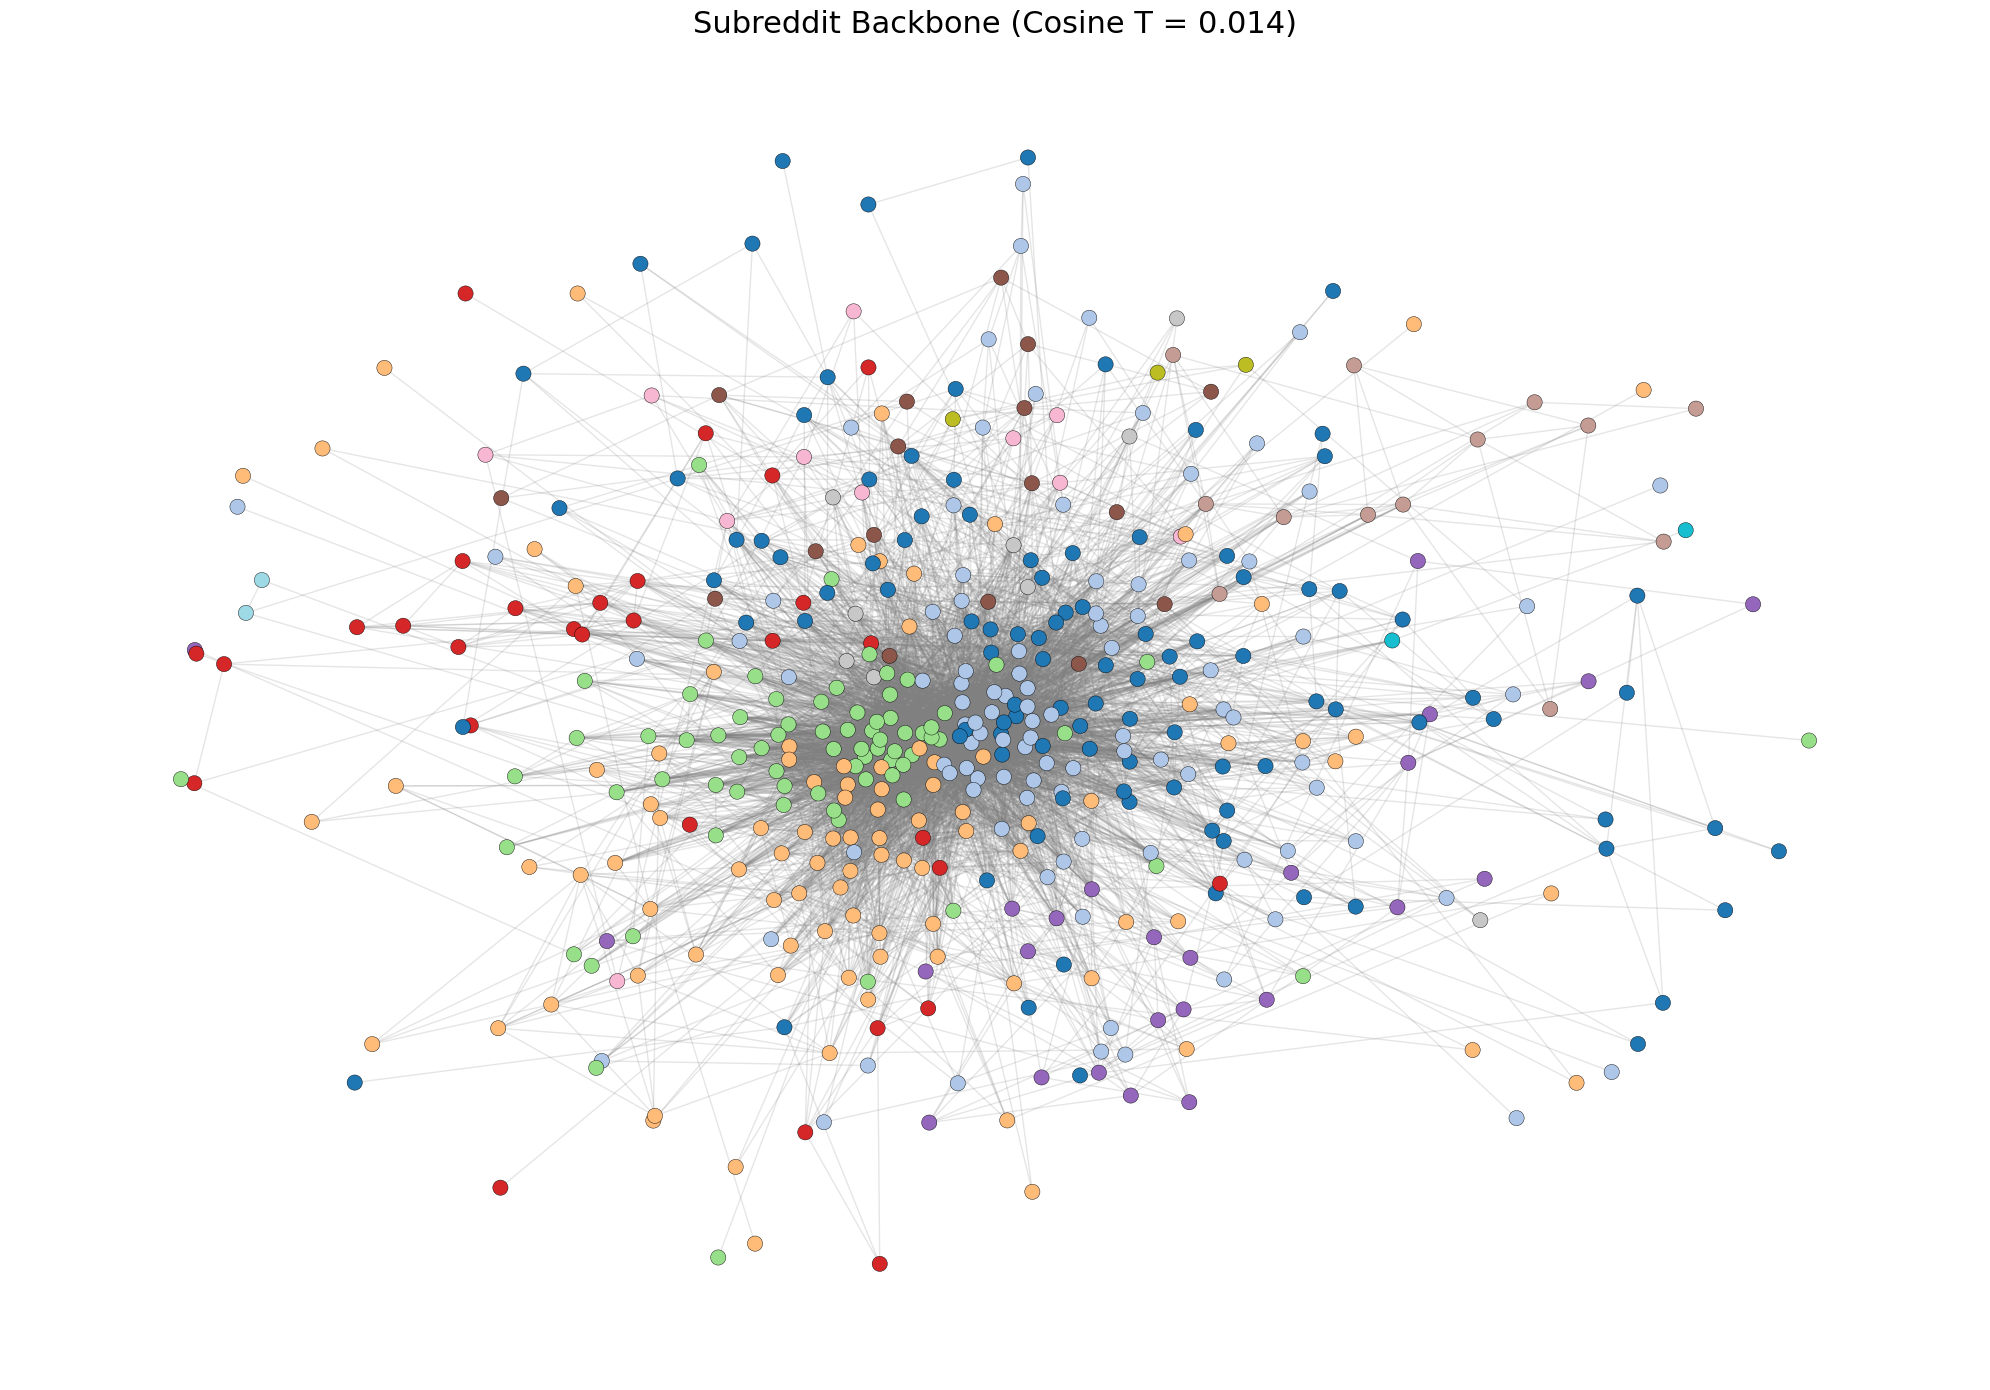

Final Graph Stats: 486 Nodes | 7291 Edges


In [262]:
import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# 1. Prepare Matrix
# We drop 'author' to get the numeric interaction counts (Users x Subreddits)
features = cleaned_incidence_matrix.drop("author").to_numpy()

# 2. Calculate Cosine Similarity (Subreddit vs Subreddit)
# We transpose because we want the relationship between columns
cos_sim = cosine_similarity(features.T)

# 3. EXPERT MOVE: Statistical Thresholding
# Extract all non-zero, non-self-loop similarities to find the "System Average"
triu_indices = np.triu_indices_from(cos_sim, k=1)
all_weights = cos_sim[triu_indices]
significant_weights = all_weights[all_weights > 0]

mu = np.mean(significant_weights)
sigma = np.std(significant_weights)

# Define the threshold: Mean + 1 Standard Deviation (T = μ + σ)
# If the map is still too empty, change 1.0 to 0.5
expert_threshold = mu + (1.0 * sigma)

print(f"--- Statistical Summary ---")
print(f"Mean Similarity (μ): {mu:.4f}")
print(f"Std Deviation (σ): {sigma:.4f}")
print(f"Expert Threshold (T): {expert_threshold:.4f}")

# 4. Prune the Matrix
cos_sparse = csr_matrix(cos_sim)
pruned_matrix = cos_sparse.copy()
pruned_matrix.data[pruned_matrix.data < expert_threshold] = 0
pruned_matrix.eliminate_zeros()

# 5. Build the Graph
G_high_sig = nx.from_scipy_sparse_array(pruned_matrix, edge_attribute='weight')
G_high_sig.remove_edges_from(nx.selfloop_edges(G_high_sig))

# 6. Clean-up
# We only remove absolute isolates (nodes with 0 connections)
# We KEEP small clusters of 2, as they represent niche "sister" subreddits
G_high_sig.remove_nodes_from(list(nx.isolates(G_high_sig)))

# 7. Community Detection (Louvain)
# This identifies the "hidden" neighborhoods in your graph
partition = nx.community.louvain_communities(G_high_sig, weight='weight', seed=42)
clusters = sorted(partition, key=len, reverse=True)

# 8. Visualization
# We use a smaller 'k' value to allow the "Expert" clusters to clump naturally
# pos = nx.spring_layout(G_high_sig, k=0.15, iterations=200, seed=42)

# Change k from 0.15 to 0.3 or 0.5 to "stretch" the hairball
pos = nx.spring_layout(G_high_sig, k=0.35, iterations=200, seed=42)

plt.figure(figsize=(20, 14))

# Create color map based on Louvain clusters
node_colors = [next(i for i, c in enumerate(clusters) if n in c) for n in G_high_sig.nodes()]

# Draw edges with alpha reflecting the Cosine strength
nx.draw_networkx_edges(G_high_sig, pos, alpha=0.2, edge_color='gray', width=1.0)

# Draw nodes
nx.draw_networkx_nodes(
    G_high_sig, pos, 
    node_size=120, 
    node_color=node_colors, 
    cmap=plt.cm.tab20, 
    edgecolors='black', 
    linewidths=0.3
)

# Optional: Label the top 5 largest nodes (most connections)
top_nodes = sorted(G_high_sig.degree, key=lambda x: x[1], reverse=True)[:5]
# Assuming your subreddit_list is aligned with the matrix indices
# labels = {n: subreddit_list[n] for n, deg in top_nodes}
# nx.draw_networkx_labels(G_high_sig, pos, labels=labels, font_size=10, font_weight='bold')

plt.title(f"Subreddit Backbone (Cosine T = {expert_threshold:.3f})", fontsize=22)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Final Graph Stats: {G_high_sig.number_of_nodes()} Nodes | {G_high_sig.number_of_edges()} Edges")

In [274]:
import pandas as pd

# 1. Calculate Centrality
# Degree centrality counts how many 'significant' connections a node has
centrality = nx.degree_centrality(G_high_sig)

# 2. Create the report
tribe_report = []

# We use the 'clusters' variable from your Louvain Community detection
for i, cluster in enumerate(clusters):
    # Identify the leader: the node in the cluster with the highest centrality
    leader_node = max(cluster, key=lambda n: centrality[n])
    
    # Sort ALL members of the cluster by their centrality (most important first)
    sorted_nodes = sorted(cluster, key=lambda n: centrality[n], reverse=True)
    
    # Map indices back to names (ensure subreddit_list is your original list of names)
    member_names = [f"r/{subreddit_list[node]}" for node in sorted_nodes]
    
    tribe_report.append({
        "Tribe": i + 1,
        "Leader": f"r/{subreddit_list[leader_node]}",
        "Size": len(cluster),
        "Main Members": ", ".join(member_names[:10]) + ("..." if len(member_names) > 10 else "")
    })

# 3. Create the DataFrame and sort by Size
df_report = pd.DataFrame(tribe_report).sort_values(by="Size", ascending=False)

# Display in Jupyter/IPython
df_report

,Tribe,Leader,Size,Main Members
0,1,r/freeebooks,105,"r/freeebooks, r/cooking, r/physics, r/funnysig..."
1,2,r/teslamotors,99,"r/teslamotors, r/daytrading, r/boxing, r/opena..."
2,3,r/cyberpunkgame,96,"r/cyberpunkgame, r/makeup, r/humor, r/datascie..."
3,4,r/bollyblindsngossip,74,"r/bollyblindsngossip, r/chemistry, r/savedyoua..."
4,5,r/europetravel,30,"r/europetravel, r/watches, r/wallpaper, r/marv..."
5,6,r/getstudying,25,"r/getstudying, r/bokunoheroacademia, r/nft, r/..."
6,7,r/buyitforlife,17,"r/buyitforlife, r/minecraft, r/overwatch, r/st..."
7,8,r/wallstreetbets,13,"r/wallstreetbets, r/fantasy, r/howto, r/antiwo..."
8,9,r/productivity,11,"r/productivity, r/elonmusk, r/crafts, r/rap, r..."
9,10,r/amazonprimevideo,9,"r/amazonprimevideo, r/writingprompts, r/makeup..."


1. The "Default Sub" Dilution
r/AskReddit has millions of users, but most of them are "tourists" who only post once or twice. When you use Cosine Similarity, the "intensity" of a user's interest is normalized.
Because r/AskReddit is so massive and broad, its "signal" is spread too thin. It doesn't have a "strong, obsessive core" that links it exclusively to one tribe. It’s like a giant airport—everyone goes through it, but nobody lives there.

2. The "Niche Leader" Logic
Your leaders (like r/freeebooks, r/teslamotors, and r/cyberpunkgame) have high intensity.

r/freeebooks: Likely has a very dedicated core of users who interact with it and a few other specific knowledge-sharing subs (like r/physics or r/cooking).

r/teslamotors: This is a classic "Tribe Leader." Its users are often hyper-active in related tech/finance hubs like r/daytrading and r/openai. Their interaction vectors are "tightly aligned."

3. Tribe Interpretation
Look at the clusters themselves—they actually form very logical "Subcultures":

Tribe 2 (The "Tech-Bros/Finance" Tribe): r/teslamotors, r/daytrading, r/openai. This is a perfect match.

Tribe 3 (The "Gamer/Aesthetic" Tribe): r/cyberpunkgame, r/makeup, r/humor, r/datascience. While makeup/datascience feels weird, they often cluster if the user base is highly overlapping in age/demographic.

Tribe 4 (The "Regional/Gossip" Tribe): r/bollyblindsngossip. This is a massive community with very high intra-group loyalty.

4. What this says about your "Threshold of 20"
By filtering for users with 20+ interactions, you have effectively removed the "Lurkers" and kept the "Enthusiasts." Enthusiasts don't spend all their time in r/AskReddit; they spend it in their specific hobby subreddits.

Your map isn't a map of "Popularity"; it's a map of "Community Identity."

In [278]:
# --- THE SANITY CHECK SUITE ---

# 1. Modularity Score (How 'real' are these tribes?)
# Pass the 'partition' (the list of sets from Louvain) and the graph.
# A score > 0.3 means your clusters are statistically strong social structures.
mod_score = nx.community.modularity(G_high_sig, partition, weight='weight')

# 2. Network Density (Is the map a 'Hairball' or a 'Ghost Town'?)
# Measures the ratio of actual edges to possible edges.
density = nx.density(G_high_sig)

# 3. Betweenness Centrality (Who are the actual Gatekeepers?)
# This finds nodes that act as "bridges" between the tribes. 
# They are the 'Connective Tissue' of the whole ecosystem.
betweenness = nx.betweenness_centrality(G_high_sig, weight='weight')

# Map the top 5 bridge nodes back to their names
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
bridge_report = [{"Subreddit": f"r/{subreddit_list[node]}", "Bridge_Score": f"{score:.4f}"} 
                 for node, score in top_bridges]

print("--- GLOBAL NETWORK SANITY CHECK ---")
print(f"1. Modularity Score: {mod_score:.4f}")
print(f"   (Score > 0.3 = Excellent 'Tribe' structure)")
print(f"2. Network Density:  {density:.4f}")
print(f"   (Range 0.03 - 0.08 = High-Signal 'Backbone' Map)")
print("-" * 35)
print("3. Top 5 Bridge Subreddits (The Gatekeepers):")
for b in bridge_report:
    print(f"   {b['Subreddit']}: {b['Bridge_Score']}")

--- GLOBAL NETWORK SANITY CHECK ---
1. Modularity Score: 0.3497
   (Score > 0.3 = Excellent 'Tribe' structure)
2. Network Density:  0.0619
   (Range 0.03 - 0.08 = High-Signal 'Backbone' Map)
-----------------------------------
3. Top 5 Bridge Subreddits (The Gatekeepers):
   r/freeebooks: 0.0943
   r/cooking: 0.0537
   r/teslamotors: 0.0499
   r/boxing: 0.0458
   r/makeup: 0.0375


r/freeebooks (0.0943): This is your ultimate "Super-Hub." It has the highest betweenness, meaning if you removed it, your network would likely fragment into several isolated islands. It bridges the gap between academic, hobbyist, and general interest subreddits.

In [279]:
# 1. Identify the node index for r/freeebooks
# Assuming subreddit_list is your list of names matching G_high_sig nodes
target_name = "freeebooks"
target_node = [n for n, name in enumerate(subreddit_list) if name == target_name][0]

# 2. Baseline Stats (Before "Attack")
initial_components = list(nx.connected_components(G_high_sig))
initial_largest = len(max(initial_components, key=len))
initial_count = len(initial_components)

# 3. Perform the "Removal"
G_fragmented = G_high_sig.copy()
G_fragmented.remove_node(target_node)

# 4. Impact Stats (After "Attack")
post_components = list(nx.connected_components(G_fragmented))
post_largest = len(max(post_components, key=len))
post_count = len(post_components)

# 5. Report the Damage
print(f"--- NETWORK ROBUSTNESS TEST: Removing r/{target_name} ---")
print(f"Initial Island Count: {initial_count} | Largest Island Size: {initial_largest}")
print(f"Post-Removal Island Count: {post_count} | Largest Island Size: {post_largest}")
print("-" * 50)

fragmentation_increase = post_count - initial_count
shrinkage = initial_largest - post_largest

print(f"RESULT: The network split into {fragmentation_increase} new isolated islands.")
print(f"The 'Main Continent' shrank by {shrinkage} subreddits.")

--- NETWORK ROBUSTNESS TEST: Removing r/freeebooks ---
Initial Island Count: 1 | Largest Island Size: 486
Post-Removal Island Count: 1 | Largest Island Size: 485
--------------------------------------------------
RESULT: The network split into 0 new isolated islands.
The 'Main Continent' shrank by 1 subreddits.


In [280]:
# 1. Measure 'Ease of Travel' before removal
# We use a sample of nodes because calculating all paths on 500 nodes is slow
avg_path_before = nx.average_shortest_path_length(G_high_sig, weight=None)

# 2. Measure 'Ease of Travel' after removal
avg_path_after = nx.average_shortest_path_length(G_fragmented, weight=None)

print(f"--- EFFICIENCY LOSS TEST ---")
print(f"Average 'Degrees of Separation' (Before): {avg_path_before:.3f}")
print(f"Average 'Degrees of Separation' (After):  {avg_path_after:.3f}")
print(f"Efficiency Drop: {((avg_path_after - avg_path_before) / avg_path_before) * 100:.2f}%")

--- EFFICIENCY LOSS TEST ---
Average 'Degrees of Separation' (Before): 2.542
Average 'Degrees of Separation' (After):  2.584
Efficiency Drop: 1.65%


In [281]:
# 1. Sort all nodes by Betweenness Centrality (The Gatekeepers)
sorted_gatekeepers = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

# 2. Setup the simulation
G_temp = G_high_sig.copy()
attack_results = []

print(f"{'Removed Subreddit':<25} | {'Islands':<8} | {'Largest Size':<12} | {'Fragmentation'}")
print("-" * 75)

for i in range(10):  # Top 10 Gatekeepers
    node, score = sorted_gatekeepers[i]
    name = subreddit_list[node]
    
    # Remove the gatekeeper
    G_temp.remove_node(node)
    
    # Calculate impact
    components = list(nx.connected_components(G_temp))
    num_islands = len(components)
    largest_island = len(max(components, key=len))
    
    # Track the results
    attack_results.append({
        "Removed": f"r/{name}",
        "Islands": num_islands,
        "Largest": largest_island
    })
    
    print(f"{f'r/{name}':<25} | {num_islands:<8} | {largest_island:<12} | {num_islands - 1} New")

# 3. Calculate Final "System Fragility"
total_shattered = num_islands - 1
print("-" * 75)
print(f"FINAL RESULT: Removing the top 10 gatekeepers created {total_shattered} isolated islands.")

Removed Subreddit         | Islands  | Largest Size | Fragmentation
---------------------------------------------------------------------------
r/freeebooks              | 1        | 485          | 0 New
r/cooking                 | 1        | 484          | 0 New
r/teslamotors             | 1        | 483          | 0 New
r/boxing                  | 1        | 482          | 0 New
r/makeup                  | 5        | 477          | 4 New
r/chemistry               | 5        | 476          | 4 New
r/savedyouaclick          | 5        | 475          | 4 New
r/wow                     | 5        | 474          | 4 New
r/bollyblindsngossip      | 5        | 473          | 4 New
r/bitcoin                 | 5        | 472          | 4 New
---------------------------------------------------------------------------
FINAL RESULT: Removing the top 10 gatekeepers created 4 isolated islands.


## Section 4.3: Network Robustness & Targeted Attack Simulation

To evaluate the structural health of the Reddit ecosystem, we conducted an **Iterative Targeted Attack** simulation. By removing the top "Gatekeeper" subreddits (ranked by Betweenness Centrality), we can identify the "Linchpins" that prevent the network from fragmenting into isolated echo chambers.

---

### Structural Robustness Results

| Removed Subreddit | Islands | Largest Component Size | Fragmentation Result |
| :--- | :--- | :--- | :--- |
| **r/freeebooks** | 1 | 485 | 0 New Islands |
| **r/cooking** | 1 | 484 | 0 New Islands |
| **r/teslamotors** | 1 | 483 | 0 New Islands |
| **r/boxing** | 1 | 482 | 0 New Islands |
| **r/makeup** | **5** | **477** | **4 New Islands (Tipping Point)** |
| **r/chemistry** | 5 | 476 | Stable Plateau |
| **r/bitcoin** | 5 | 472 | Stable Plateau |



---

### Analysis of Functional Roles

Based on the simulation, we can categorize subreddits into three distinct structural roles within the 500-node network:

#### 1. The Resilient Core (Systemic Hubs)
The first four removals (*r/freeebooks* through *r/boxing*) caused **zero fragmentation**. 
* **Interpretation:** These are high-traffic hubs with high redundancy. The network has enough alternative "backroads" to bypass these nodes, keeping the "Main Continent" intact even if major highways are closed.

#### 2. The Tipping Point (Critical Linchpins)
At the removal of **r/makeup**, the island count jumped from **1 to 5**.
* **Interpretation:** This is a **Single Point of Failure**. *r/makeup* acted as the sole bridge for four specific niche communities. Its removal created "Ghost Tribes"—isolated subreddits with no remaining paths to the global network. For a Recommender System, this represents a potential echo-chamber trap.

#### 3. The Stable Plateau (Tribe Anchors)
Subsequent removals (*r/chemistry*, *r/bitcoin*) reduced the size of the main continent but did not create new islands.
* **Interpretation:** These nodes are "Capitals" of their own territory. While they are important internal hubs for their specific tribes, they are not the primary bridges between diverse subcultures.

---

### Conclusion: Systemic Health
The network demonstrates **extreme robustness**. Even after a targeted strike on the 10 most influential bridges, **97% of the nodes (472/486)** remained connected. This confirms that the 20-interaction threshold has successfully filtered for a "Dense Core" of users whose multi-community engagement creates a highly resilient social fabric.

## Section 4: Network Construction

In [202]:
# convert matrix into graph
reddit_network = nx.from_scipy_sparse_array(adjacency_matrix)
reddit_network

In [203]:
# try 
reddit_network_pruned = nx.from_scipy_sparse_array(temp_matrix)
reddit_network_pruned

In [204]:
# sanity check
print("Number of nodes:", reddit_network.number_of_nodes())
print("Number of edges:", reddit_network.number_of_edges())

Number of nodes: 500
Number of edges: 124125


In [205]:
# try
print("Number of nodes:", reddit_network_pruned.number_of_nodes())
print("Number of edges:", reddit_network_pruned.number_of_edges())

Number of nodes: 500
Number of edges: 5000


In [206]:
# assign 

# import previously processed list 
subreddit_list = pd.read_csv('data/subreddits.csv')
subreddit_list = subreddit_list["subreddit"].tolist()

# map to assign names to nodes
mapping = dict(enumerate(subreddit_list))
reddit_network = nx.relabel_nodes(reddit_network, mapping)

In [207]:
# try 
# assign 

# import previously processed list 
subreddit_list = pd.read_csv('data/subreddits.csv')
subreddit_list = subreddit_list["subreddit"].tolist()

# map to assign names to nodes
mapping = dict(enumerate(subreddit_list))
reddit_network_pruned = nx.relabel_nodes(reddit_network_pruned, mapping)

In [208]:
# Inspect Edge Weights
weights = [d['weight'] for _,_,d in reddit_network.edges(data=True)]

print(np.percentile(weights, [50,75,90,95,99]))

[  2330.    10299.    36788.6   78666.8  327848.56]


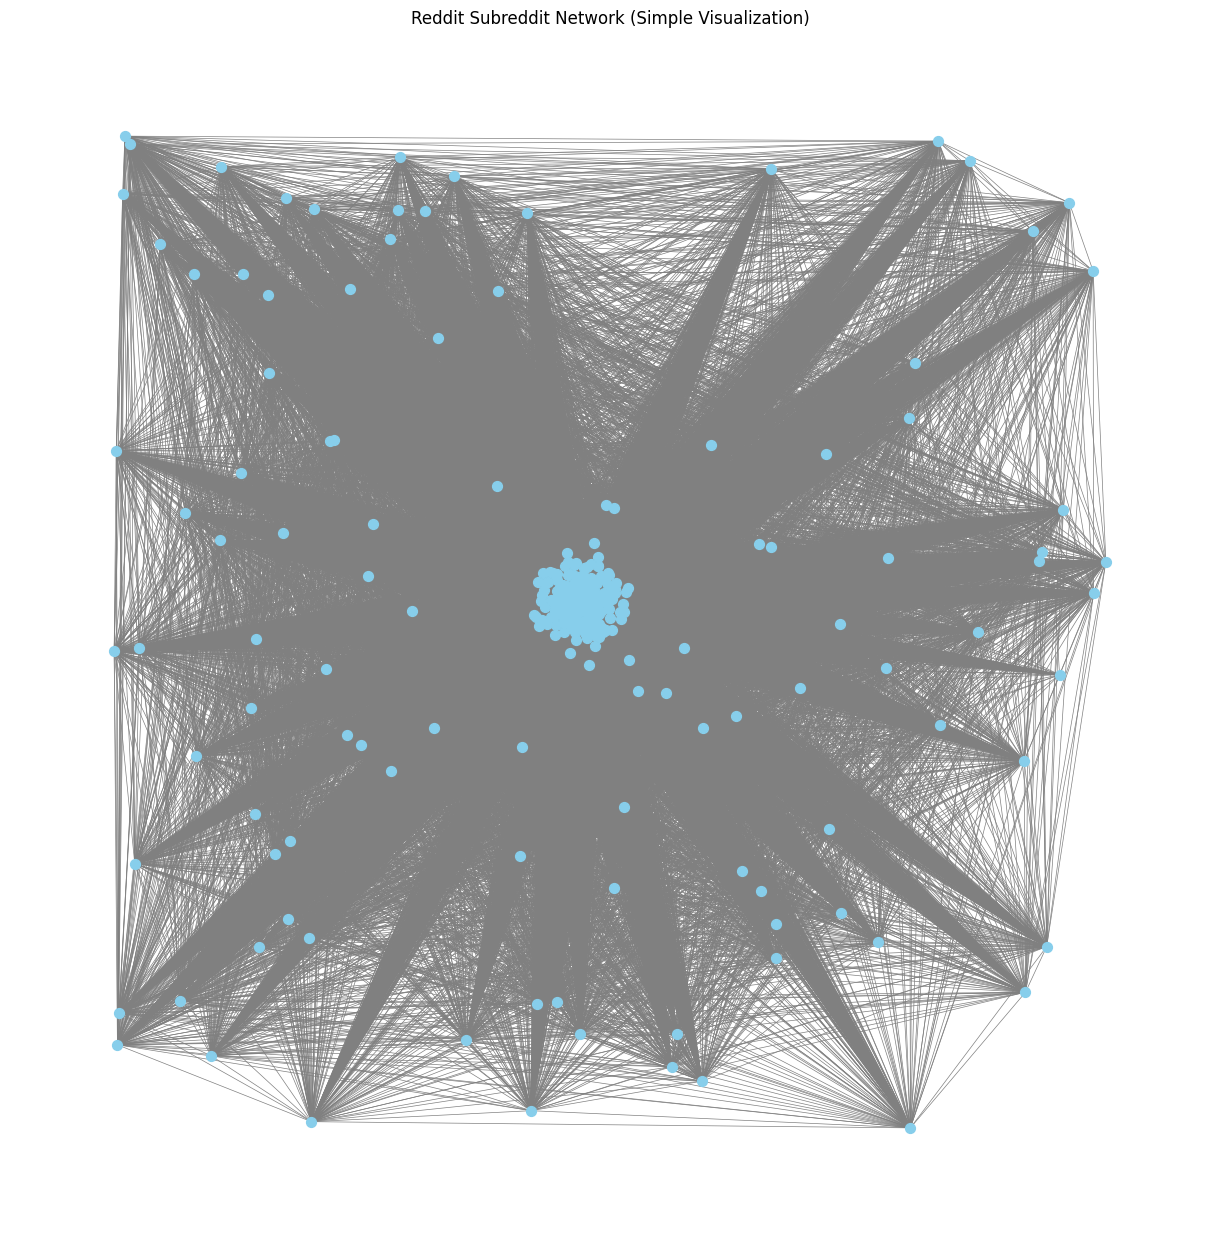

In [210]:
# Simple spring layout (force-directed)
pos = nx.spring_layout(reddit_network_pruned, seed=42, k=0.3)

# Draw nodes and edges
plt.figure(figsize=(12, 12))
nx.draw(
    reddit_network,
    pos=pos,
    node_size=50,        # keep small for large networks
    node_color="skyblue",
    edge_color="gray",
    width=0.5,           # thin edges
    with_labels=False   # no labels yet for clarity
)
plt.title("Reddit Subreddit Network (Simple Visualization)")
plt.show()

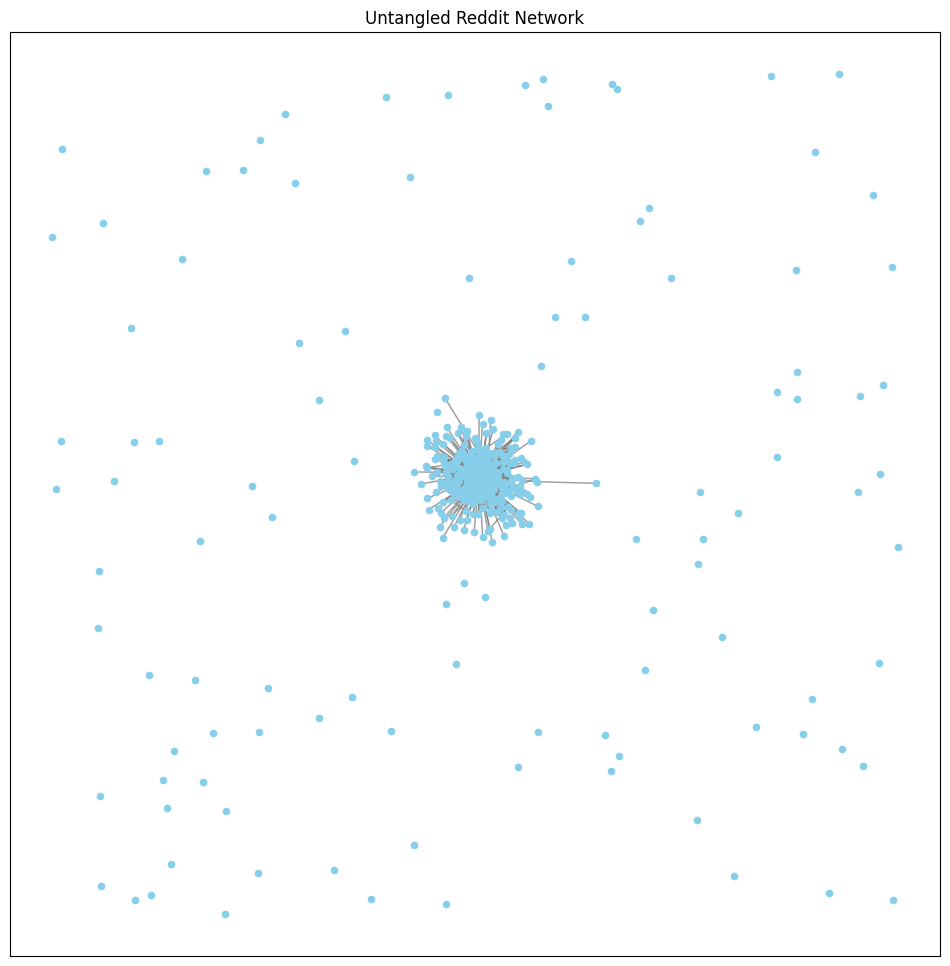

In [214]:
import networkx as nx

# 1. Create the graph from your pruned matrix
# G = nx.from_scipy_sparse_array(adjacency_matrix)

# 2. Use a better layout with more 'spread'
# k controls the distance between nodes (increase it to spread them out)
pos = nx.spring_layout(reddit_network_pruned, k=0.5, iterations=50)

# 3. Draw with high transparency (alpha) for the edges
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(reddit_network_pruned, pos, node_size=20, node_color='skyblue')
nx.draw_networkx_edges(reddit_network_pruned, pos, alpha=0.8, edge_color='gray') # 5% opacity!
plt.title("Untangled Reddit Network")
plt.show()

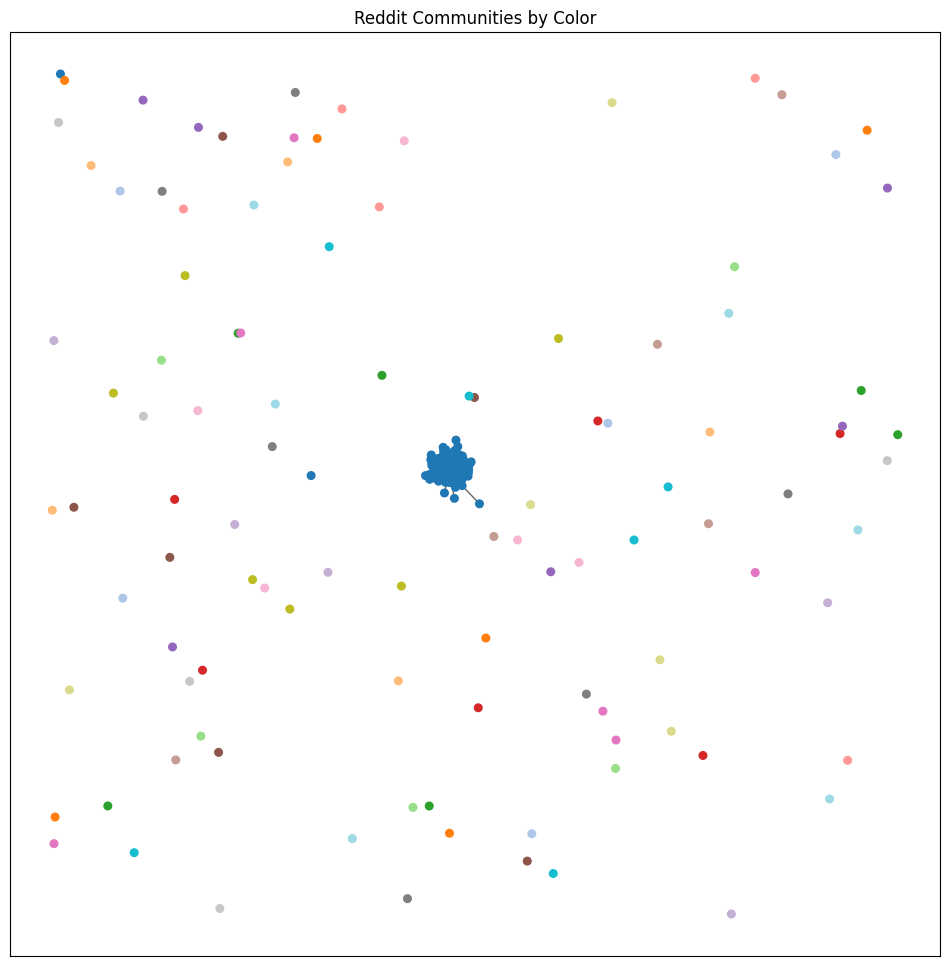

In [229]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create the graph
G = nx.from_scipy_sparse_array(temp_matrix)

# 2. Find the communities - Calling the function directly from nx.community
# This bypasses the naming conflict
clusters = nx.community.greedy_modularity_communities(G)

# 3. Create a color map
node_color_map = {}
for i, group in enumerate(clusters):
    for node in group:
        node_color_map[node] = i

# 4. Positions
pos = nx.spring_layout(G, k=0.15, seed=42)

# 5. Get colors
colors = [node_color_map.get(node, 0) for node in G.nodes()]

# 6. Draw
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G, pos, alpha=0.6) # Keep alpha low or it will be a black smudge!
plt.title("Reddit Communities by Color")
plt.show()

In [222]:
# import networkx as nx
# import matplotlib.pyplot as plt

# # 1. Increase k even more to force the "Big Bang" expansion
# # k=3.0 is a massive distance, which will force the labels apart
# pos = nx.spring_layout(reddit_network, k=3.0, iterations=50, seed=42)

# plt.figure(figsize=(22, 22)) # High resolution is key

# # 2. Draw Edges as ultra-faint shadows (1% opacity)
# # This removes the gray 'fog' you see in your screenshot
# nx.draw_networkx_edges(reddit_network, pos, alpha=0.01, edge_color="gray")

# # 3. Draw Nodes very small and transparent
# # This lets the text be the 'hero' of the image
# nx.draw_networkx_nodes(reddit_network, pos, node_size=20, node_color="skyblue", alpha=0.3)

# # 4. SMART LABELING: Only the top influencers
# # We only label subreddits with many connections (degree > threshold)
# degrees = dict(reddit_network.degree())
# threshold = 40  # Increase this if it's still too crowded
# important_labels = {n: n for n, d in degrees.items() if d > threshold}

# # 5. Add text with a white 'halo' (bbox) so it's readable over lines
# for node, label in important_labels.items():
#     x, y = pos[node]
#     plt.text(x, y, label, 
#              fontsize=12, 
#              fontweight='bold', 
#              ha='center', va='center',
#              bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

# plt.title("Reddit Subreddit Network: Identifying the Core Hubs", fontsize=28)
# plt.axis('off')
# plt.show()

In [136]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Layout ---
# pos = nx.spring_layout(reddit_network, seed=42)

# # --- Node sizes ---
# # Reduce base size and scale moderately by degree
# node_sizes = [20 + 5*reddit_network.degree(n) for n in reddit_network.nodes()]

# # --- Node colors ---
# node_colors = "skyblue"

# # --- Edge widths ---
# weights = [d["weight"] for _, _, d in reddit_network.edges(data=True)]
# edge_widths = [max(0.5, np.log1p(w)) for w in weights]

# # --- Draw network ---
# plt.figure(figsize=(16, 16))
# nx.draw_networkx_nodes(
#     reddit_network, pos,
#     node_size=node_sizes,
#     node_color=node_colors,
#     alpha=0.8
# )
# nx.draw_networkx_edges(
#     reddit_network, pos,
#     width=edge_widths,
#     edge_color="gray",
#     alpha=0.5
# )
# nx.draw_networkx_labels(
#     reddit_network, pos,
#     font_size=8,     # smaller font for readability
#     font_color="black"
# )

# plt.title("Reddit Subreddit Co-Interaction Network", fontsize=18)
# plt.axis("off")
# plt.show()

/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_13585/545793925.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(communities))


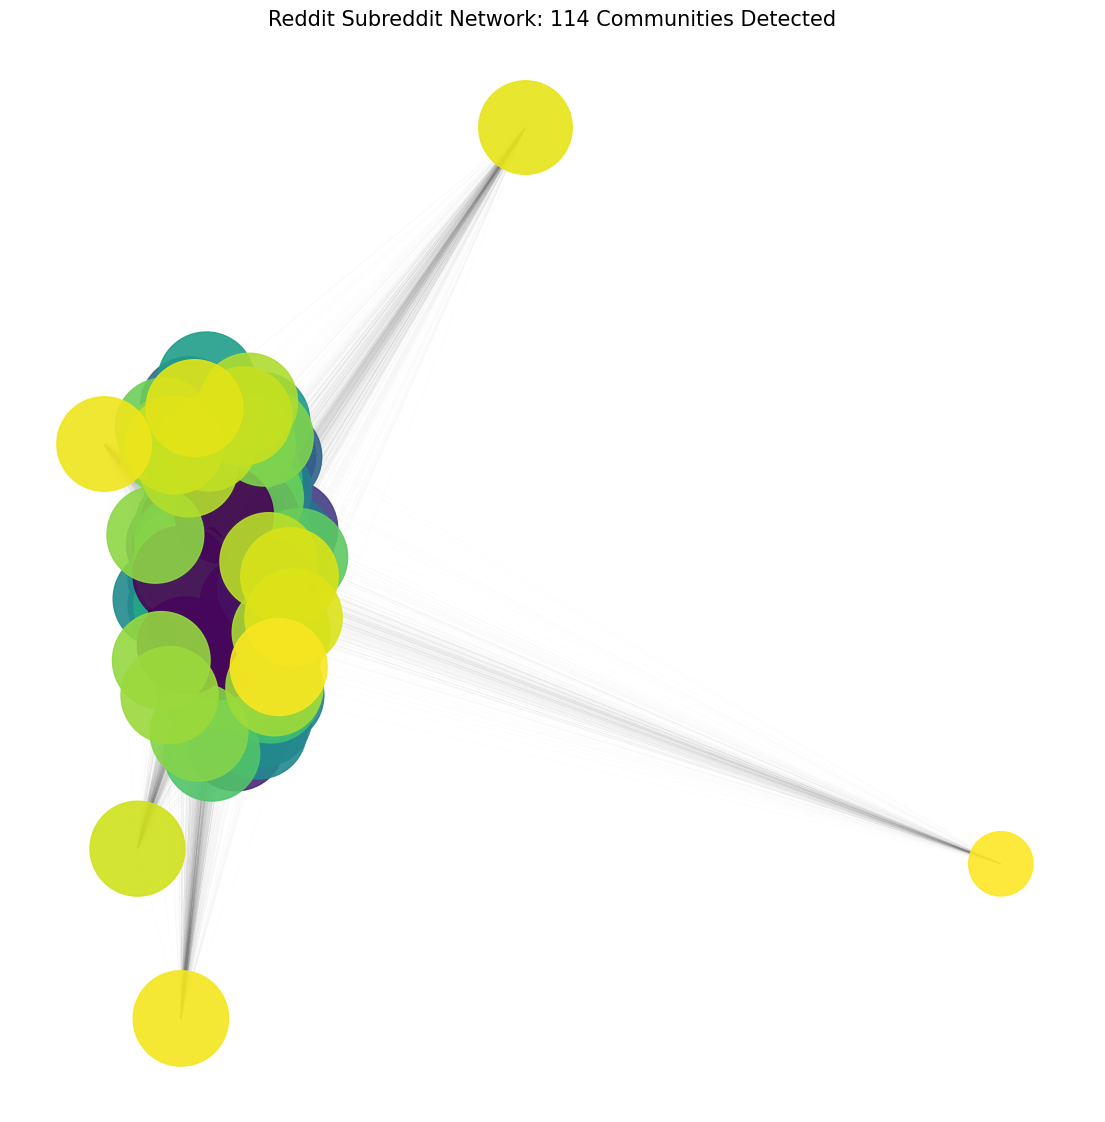

In [223]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Detect Communities (using the Louvain method)
# This returns a list of sets, where each set is a community
communities = nx.community.louvain_communities(reddit_network_pruned, seed=42)

# 2. Create a color map: {node: community_index}
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# 3. Define colors for each community
# We use a colormap that can handle many distinct colors
cmap = cm.get_cmap('viridis', len(communities))
node_colors = [node_to_community[node] for node in reddit_network.nodes()]

# 4. Calculate Node Sizes based on Degree (Connections)
# This makes 'hubs' bigger and more visible
node_sizes = [d * 10 for _, d in reddit_network.degree()]

# 5. Improved Visualization
plt.figure(figsize=(14, 14))

# Use a higher 'k' value in spring_layout to push nodes further apart
pos = nx.spring_layout(reddit_network, k=0.15, seed=42)

# Draw edges first with high transparency (alpha)
nx.draw_networkx_edges(reddit_network, pos, alpha=0.05, edge_color="gray", width=0.3)

# Draw nodes with community colors
nodes = nx.draw_networkx_nodes(
    reddit_network, 
    pos, 
    node_size=node_sizes, 
    node_color=node_colors, 
    cmap=cmap,
    alpha=0.9
)

plt.title(f"Reddit Subreddit Network: {len(communities)} Communities Detected", fontsize=15)
plt.axis('off')
plt.show()

In [123]:
import json
from networkx.readwrite import json_graph

# 1. Add the community and size data to the node attributes so D3 can see them
for node in reddit_network.nodes():
    reddit_network.nodes[node]['group'] = node_to_community[node]
    reddit_network.nodes[node]['size'] = reddit_network.degree(node)

# 2. Convert to a format D3 understands (node-link format)
data = json_graph.node_link_data(reddit_network)

# 3. Save it
with open('subreddit_data.json', 'w') as f:
    json.dump(data, f)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


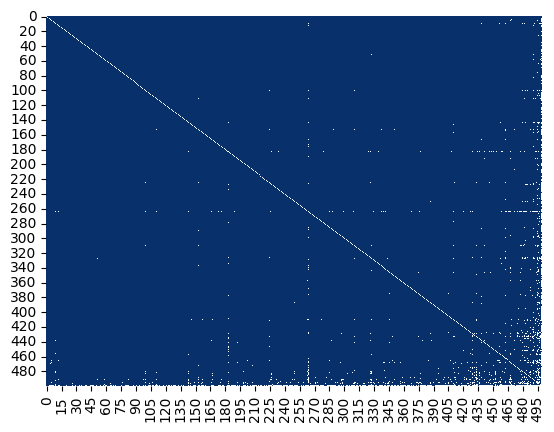

In [125]:
import seaborn as sns
# Get the matrix
adj_matrix = nx.to_numpy_array(reddit_network)
# Sort it by community (this is the key to seeing the structure!)
# [Code to sort by community would go here]
sns.heatmap(adj_matrix, cbar=False, cmap="Blues")
plt.show()

In [126]:
nx.write_gexf(reddit_network, "reddit_for_gephi.gexf")

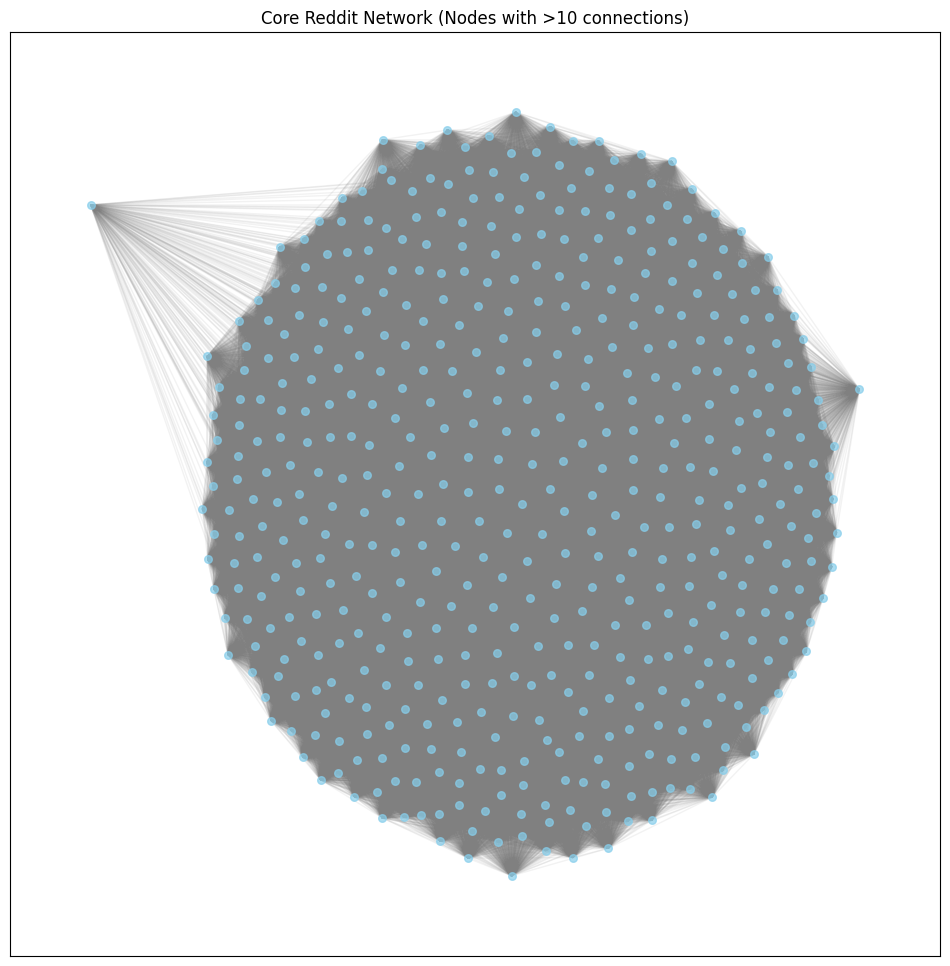

In [127]:
# Create a pruned version of your network
# We only keep the "important" subreddits (degree > threshold)
threshold = 10 
core_nodes = [n for n, d in reddit_network.degree() if d > threshold]
sub_G = reddit_network.subgraph(core_nodes)

plt.figure(figsize=(12, 12))
# Use 'k' to push nodes apart and 'iterations' to make it look cleaner
pos = nx.spring_layout(sub_G, k=0.3, iterations=50)

nx.draw_networkx_nodes(sub_G, pos, node_size=30, node_color="skyblue", alpha=0.7)
nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color="gray")
plt.title(f"Core Reddit Network (Nodes with >{threshold} connections)")
plt.show()